# MMJL Capture and Notebook-State Regression Test

**1. Markdown cell — test purpose and execution order**

This notebook tests:

1. repository-root discovery from anywhere inside the repository
2. `src/` import setup
3. MMJL utility imports
4. Jupyter magic registration
5. literal Markdown and HTML logging
6. `%%jupy_capture`
7. the `%%jupy_tee` alias
8. failed notebook-state execution in visible order:
   `A -> B -> C`
9. successful recovery by moving backward:
   `B -> A`
10. stdout, exception, rich-display, and Matplotlib capture
11. `%jupy_file`
12. manifest inspection and validation
13. Markdown and HTML timeline generation
14. the Python analogs of `tree`, `wc -l`, and `cat`

The notebook-state dependency graph is:

```text
C creates numbers
B consumes numbers and creates squared_numbers
A consumes numbers and squared_numbers, computes a mean, and plots
```

The cells are displayed as:

```text
A
B
C
B again
A again
```

Therefore the first A and B should fail, C should succeed, and the
subsequent B and A should succeed.

---

**Looking further**:

Here is the complete notebook sequence. The intended execution order is the notebook's ordinary top-to-bottom order, with the exception of the A → B → C → B → A example

---

**Let's go!!!**<br/><br/>

In [1]:
## 2. Code cell 01 — locate the repository root and configure `sys.path`
import importlib
import os
import sys
import pathlib

starting_dir = pathlib.Path.cwd().resolve()
repo_root = None
src_path = None
package_path = None

for candidate_path in [starting_dir, *starting_dir.parents]:
    package_path = (
        candidate_path
        / "src"
        / "multimodal_jupy_logger"
    )

    if package_path.is_dir():
        repo_root = candidate_path
        break
    ##endof:  if package_path.is_dir()
##endof:  for candidate_path in [...]

if repo_root is None:
    raise RuntimeError(
        "Could not find a repository root containing "
        "src/multimodal_jupy_logger."
    )
##endof:  if repo_root is None

src_path = repo_root / "src"

os.chdir(repo_root)

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
##endof:  if str(src_path) not in sys.path

importlib.invalidate_caches()

print("starting_dir:", starting_dir)
print("repo_root:", repo_root)
print("src_path:", src_path)
print("current working directory:", pathlib.Path.cwd())
print("Python executable:", sys.executable)

starting_dir: D:\David\my_repos_dwb\multimodal-jupy-logger\examples
repo_root: D:\David\my_repos_dwb\multimodal-jupy-logger
src_path: D:\David\my_repos_dwb\multimodal-jupy-logger\src
current working directory: D:\David\my_repos_dwb\multimodal-jupy-logger
Python executable: D:\David\my_repos_dwb\multimodal-jupy-logger\.venv_mmjl_test\Scripts\python.exe


In [2]:
## 3. Code cell 02 — import MMJL and the path-display utilities
from multimodal_jupy_logger import (
    MultimodalJupyLogger,
    jupy_logger_register,
    register_jupy_logger,
)

from multimodal_jupy_logger.utils import (
    count_lines,
    path_display,
    print_file,
    tree,
)

from multimodal_jupy_logger.utils import path_display as dpypd

print("MMJL imports succeeded.")
print("path_display module:", dpypd)

MMJL imports succeeded.
path_display module: <module 'multimodal_jupy_logger.utils.path_display' from 'D:\\David\\my_repos_dwb\\multimodal-jupy-logger\\src\\multimodal_jupy_logger\\utils\\path_display.py'>


## Manifest and Artifact Lookup Helpers

This notebook is a development lab, so this cell gives us stable ways to
inspect MMJL output after a kernel restart. The manifest and artifacts live
on disk, even when Python state is gone.

Use examples:

```python
show_manifest()
show_manifest(label_contains="abc-second-pass-a")
show_artifact(23)
```


In [3]:
## Code cell 03

## Development helper cell -- inspect manifest rows and artifacts.
## This cell is notebook-local; it is not part of the MMJL public API.

import csv
import json
import mimetypes
import pathlib

from typing import Any

from IPython.display import HTML, Image, Markdown, display


ManifestRow = dict[str, Any]


def find_repo_root(
      starting_dir: pathlib.Path | str | None = None,
    ) -> pathlib.Path:
    '''
    Find the repository root from the current notebook location.
    '''

    starting_path = (
        pathlib.Path.cwd()
        if starting_dir is None
        else pathlib.Path(starting_dir)
    )
    starting_path = starting_path.resolve()

    for candidate_path in [starting_path, *starting_path.parents]:
        package_path = (
            candidate_path
            / "src"
            / "multimodal_jupy_logger"
        )

        if package_path.is_dir():
            return candidate_path
        ##endof:  if package_path.is_dir()
    ##endof:  for candidate_path in [...]

    raise RuntimeError("Could not find MMJL repository root.")
##endof:  find_repo_root


def read_mmjl_manifest(
      log_root: pathlib.Path | str | None = None,
    ) -> tuple[pathlib.Path, list[ManifestRow]]:
    '''
    Read the MMJL manifest as TSV rows.
    '''

    if log_root is None:
        local_repo_root = find_repo_root()
        log_root = local_repo_root / "jupy_log"
    ##endof:  if log_root is None

    log_root = pathlib.Path(log_root)
    manifest_path = log_root / "manifest.tsv"

    with manifest_path.open("r", encoding="utf-8", newline="") as handle:
        rows = list(csv.DictReader(handle, delimiter="\t"))
    ##endof:  with manifest_path.open(...)

    return manifest_path, rows
##endof:  read_mmjl_manifest


def _row_int(
      row: ManifestRow,
      key: str,
      default: int = -1,
    ) -> int:
    '''
    Read an integer-ish manifest field for sorting/filtering.
    '''

    value = row.get(key, "")

    try:
        return int(value)
    except (TypeError, ValueError):
        return default
    ##endof:  try/except (TypeError, ValueError)
##endof:  _row_int


def show_manifest(
      limit: int = 20,
      log_root: pathlib.Path | str | None = None,
      label_contains: str | None = None,
    ) -> None:
    '''
    Print a compact view of recent manifest rows.
    '''

    manifest_path, rows = read_mmjl_manifest(log_root=log_root)

    if label_contains is not None:
        rows = [
            row for row in rows
            if label_contains.lower() in row.get("label", "").lower()
        ]
    ##endof:  if label_contains is not None

    rows = sorted(
        rows,
        key=lambda row: _row_int(row, "artifact_sequence"),
    )

    print(f"manifest: {manifest_path}")
    print(f"rows: {len(rows)}")
    print()

    for row in rows[-limit:]:
        print(
            row.get("artifact_sequence", ""),
            row.get("capture_sequence", ""),
            row.get("role", ""),
            row.get("mime", ""),
            row.get("label", ""),
            row.get("path", ""),
            sep=" | ",
        )
    ##endof:  for row in rows[-limit:]
##endof:  show_manifest


def get_artifact_row(
      artifact_sequence: int,
      log_root: pathlib.Path | str | None = None,
    ) -> tuple[pathlib.Path, ManifestRow]:
    '''
    Return the manifest row for one artifact sequence.
    '''

    manifest_path, rows = read_mmjl_manifest(log_root=log_root)
    target = int(artifact_sequence)

    for row in rows:
        if _row_int(row, "artifact_sequence") == target:
            return manifest_path, row
        ##endof:  if _row_int(row, "artifact_sequence") == target
    ##endof:  for row in rows

    raise KeyError(f"No artifact_sequence found: {artifact_sequence}")
##endof:  get_artifact_row


def resolve_artifact_path(
      manifest_path: pathlib.Path | str,
      row: ManifestRow,
    ) -> pathlib.Path:
    '''
    Resolve a manifest artifact path against the manifest directory.
    '''

    manifest_dir = pathlib.Path(manifest_path).parent
    artifact_path = pathlib.Path(row.get("path", ""))

    if not artifact_path.is_absolute():
        artifact_path = manifest_dir / artifact_path
    ##endof:  if not artifact_path.is_absolute()

    return artifact_path.resolve()
##endof:  resolve_artifact_path


def show_artifact(
      artifact_sequence: int,
      log_root: pathlib.Path | str | None = None,
    ) -> ManifestRow:
    '''
    Display one logged artifact by its monotonic artifact sequence.
    '''

    manifest_path, row = get_artifact_row(
        artifact_sequence,
        log_root=log_root,
    )
    artifact_path = resolve_artifact_path(manifest_path, row)
    guessed_mime = mimetypes.guess_type(artifact_path)[0]
    mime = row.get("mime", "") or guessed_mime or ""

    print(f"artifact_sequence: {row.get('artifact_sequence')}")
    print(f"capture_sequence: {row.get('capture_sequence')}")
    print(f"role: {row.get('role')}")
    print(f"label: {row.get('label')}")
    print(f"mime: {mime}")
    print(f"path: {artifact_path}")
    print(f"exists: {artifact_path.exists()}")
    print()

    if not artifact_path.exists():
        return row
    ##endof:  if not artifact_path.exists()

    if mime == "image/png":
        display(Image(filename=str(artifact_path)))
    elif mime == "image/svg+xml":
        display(HTML(artifact_path.read_text(encoding="utf-8")))
    elif mime in ["text/markdown", "text/x-markdown"]:
        display(Markdown(artifact_path.read_text(encoding="utf-8")))
    elif mime == "text/html":
        display(HTML(artifact_path.read_text(encoding="utf-8")))
    elif mime == "application/json":
        print(json.dumps(
            json.loads(artifact_path.read_text(encoding="utf-8")),
            indent=2,
        ))
    elif mime.startswith("text/"):
        print(artifact_path.read_text(
            encoding="utf-8",
            errors="replace",
        ))
    else:
        print("No display rule for this MIME type.")
    ##endof:  if/elif MIME display

    return row
##endof:  show_artifact


def display_banner(my_char: str='-', my_len: int=65) -> None: 
    print(my_len*my_char)
##endof:  display_banner(...)

In [4]:
## 4. Code cell 04 — prove both utility import styles work

print("Directly imported function:")
print("  tree:", tree)

print("\nModule-namespace functions:")
print("  dpypd.tree:", dpypd.tree)
print("  dpypd.count_lines:", dpypd.count_lines)
print("  dpypd.print_file:", dpypd.print_file)

print("\nDirect and module attributes refer to the same functions:")
print("  tree is dpypd.tree:", tree is dpypd.tree)
print(
    "  count_lines is dpypd.count_lines:",
    count_lines is dpypd.count_lines,
)
print(
    "  print_file is dpypd.print_file:",
    print_file is dpypd.print_file,
)

Directly imported function:
  tree: <function tree at 0x000002C4CA9AA340>

Module-namespace functions:
  dpypd.tree: <function tree at 0x000002C4CA9AA340>
  dpypd.count_lines: <function count_lines at 0x000002C4CA9AA3E0>
  dpypd.print_file: <function print_file at 0x000002C4CA9AA480>

Direct and module attributes refer to the same functions:
  tree is dpypd.tree: True
  count_lines is dpypd.count_lines: True
  print_file is dpypd.print_file: True


In [5]:
## 5. Code cell 05 — show the relevant repository tree

dpypd.tree(
    this_dir=repo_root,
    dirs_to_exclude=[
        ".git",
        "__pycache__",
        ".venv",
        ".venv_test_mmjl",
        ".ipynb_checkpoints",
    ],
    files_to_exclude=[
        ".pyc",
    ],
)

+ D:\David\my_repos_dwb\multimodal-jupy-logger
    + .gitattributes
    + .gitignore
    + docs/
        + dev_notes/
            + first_mmjl_smoke_test_2026-06-14.md
            + git_changing_executed_filename_learning_2026-06-17.md
            + jupyter_cell_magic_first_line_learning_2026-06-17.md
            + mmjl_capture_and_state_testing_-_PLAN_2026-06-16.md
            + template_both_better.py
            + template_count_lines.py
            + template_print_file.py
    + examples/
        + complete_pre_jupyter_lab_powershell_io_2026-06-14T152800-0400.log
        + mmjl_capture_and_state_smoke_test.ipynb
        + mmjl_capture_and_state_smoke_test_1781817012.ipynb
        + mmjl_capture_debugging_lab.ipynb
        + mmjl_first_smoke_test.ipynb
        + mmjl_quickstart_demo.ipynb
        + test_setup_and_start.md
    + LICENSE
    + README.md
    + repr_win_laptop_init__requirements.txt
    + reproducibility_win_init__requirements.txt
    + requirements-ml.txt
    + require

For:  **6**

Run this after restarting the kernel and loading the updated files. 
(If you've run the last cells, this is almost certainly done.)

```python
register_jupy_logger()
```

Expected registration text includes:

```text
%%jupy_log
%%jupy_capture
%%jupy_tee
```

In [6]:
## 6. Code cell 06 — register the magics

register_jupy_logger()

[DONE] Registered: %jupy_save, %jupy_file, %%jupy_log, %%jupy_capture, %%jupy_tee, %jupy_markdown, %jupy_html, %jupy_inspect, %jupy_validate


In [7]:
## 7. Code cell 07 — verify that the magics exist

ipython_shell = get_ipython()

magic_names = [
    "jupy_save",
    "jupy_file",
    "jupy_log",
    "jupy_capture",
    "jupy_tee",
    "jupy_markdown",
    "jupy_html",
    "jupy_inspect",
    "jupy_validate",
]

for magic_name in magic_names:
    line_magic = ipython_shell.find_line_magic(magic_name)
    cell_magic = ipython_shell.find_cell_magic(magic_name)

    print(
        f"{magic_name:16s}",
        f"line={line_magic is not None}",
        f"cell={cell_magic is not None}",
    )
##endof:  for magic_name in magic_names

jupy_save        line=True cell=False
jupy_file        line=True cell=False
jupy_log         line=False cell=True
jupy_capture     line=False cell=True
jupy_tee         line=False cell=True
jupy_markdown    line=True cell=False
jupy_html        line=True cell=False
jupy_inspect     line=True cell=False
jupy_validate    line=True cell=False


**8. Markdown cell — notebook-native hidden-text control**

This cell tests Jupyter’s own Markdown rendering independently of MMJL.

```markdown
<strong>Notebook-native `<details>` control</strong>

<details>
<summary>Click the arrow to reveal the notebook-native text</summary>

This text lives directly in a Jupyter Markdown cell.

If clicking the arrow reveals this paragraph, the notebook frontend is
rendering the HTML element correctly.

</details>
```

---

_DWB Note: I think we want to test the following:_

<strong>Notebook-native `<details>` control</strong>

<details>
<summary>Click the arrow to reveal the notebook-native text</summary>

This text lives directly in a Jupyter Markdown cell.

If clicking the arrow reveals this paragraph, the notebook frontend is
rendering the HTML element correctly.

</details>

<br/><hr/>

For **9** (`Code cell 08 — log the original Markdown regression case`)

This preserves the original test: raw `<details>` HTML stored with the
`text/markdown` MIME type.

In [8]:
%%jupy_log --label details-summary-markdown-regression --mime text/markdown
<details>
<summary>Click the arrow to reveal logged Markdown text</summary>

This content was logged as `text/markdown`.

The regression question is whether exported timelines preserve this as
renderable Markdown/HTML or incorrectly turn it into escaped or fenced
source text.

</details>

<!-- ## 9. Code cell 08 — log the original Markdown regression case -->
<!--   If I had left the python comment without the HTML comment,   -->
<!-- + it would have rendered as an `h2`. But you might only see    -->
<!-- + this in the dpypd.print_file version.                        -->

<br/>HTML comments above.<br/>Hopefully you can see the utility of jupy_log
as a note-taking device.

[DONE] Logged text: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md


For **10** (`Code cell 09 — log an HTML control version`)

This distinguishes a general `<details>` failure from a Markdown-MIME
rendering-policy failure.

With the current timeline builder, the expected distinction is:

* `text/html`: should render as a collapsible block in the HTML timeline
* `text/markdown`: currently may appear as escaped/fenced source

That would identify a timeline-rendering issue, not a capture failure.

In [9]:
%%jupy_log --label details-summary-html-control --mime text/html
<details>
<summary>Click the arrow to reveal logged HTML text</summary>

<p>
This content was logged as <code>text/html</code>. It should be inserted
as HTML in the generated HTML timeline.
</p>

</details>

## 10. Code cell 09 — log an HTML control version

<!--   I can leave the python comment above as-is, since this is -->
<!-- + HTML and not markdown. But you might only see this in the -->
<!-- + dpypd.print_file version.                                 -->

<br/>HTML comments above.<br/>Hopefully you can see the utility of jupy_log
as a note-taking device.

[DONE] Logged text: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html


In [10]:
# Code cell 10

dpypd.tree(
    this_dir=repo_root,
    dirs_to_exclude=[
        ".git",
        "__pycache__",
        ".venv",
        ".venv_test_mmjl",
        ".ipynb_checkpoints",
    ],
    files_to_exclude=[
        ".pyc",
    ],
)

+ D:\David\my_repos_dwb\multimodal-jupy-logger
    + .gitattributes
    + .gitignore
    + docs/
        + dev_notes/
            + first_mmjl_smoke_test_2026-06-14.md
            + git_changing_executed_filename_learning_2026-06-17.md
            + jupyter_cell_magic_first_line_learning_2026-06-17.md
            + mmjl_capture_and_state_testing_-_PLAN_2026-06-16.md
            + template_both_better.py
            + template_count_lines.py
            + template_print_file.py
    + examples/
        + complete_pre_jupyter_lab_powershell_io_2026-06-14T152800-0400.log
        + mmjl_capture_and_state_smoke_test.ipynb
        + mmjl_capture_and_state_smoke_test_1781817012.ipynb
        + mmjl_capture_debugging_lab.ipynb
        + mmjl_first_smoke_test.ipynb
        + mmjl_quickstart_demo.ipynb
        + test_setup_and_start.md
    + jupy_log/
        + artifacts/
            + 000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md
            + 000002_17824

In [11]:
## Code cell 11

dpypd.tree(f"{repo_root}/jupy_log")

+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md
        + 000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
    + manifest.tsv
    + staging/
    + timelines/


Found the file-not-found bug, don't need debugging as code cell

```python
#  PREVIOUSLY: Code cell 11.5 -- debug with dir

!dir .\jupy_log\artifacts\ | findstr /V "Serial"`
```

In [12]:
## Code cell 12, better manifest display, probably won't need tree every time.

display_banner()
show_manifest(limit=20)
display_banner()
print()
print("That's the previous tries and the start of this one...")
print("Unless, as is the case now, this is a different machine,")
print("so there are only the two new entries.")

-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 2

000001 |  | literal | text/markdown | details-summary-markdown-regression | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md
000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
-----------------------------------------------------------------

That's the previous tries and the start of this one...
Unless, as is the case now, this is a different machine,
so there are only the two new entries.


<br/><hr/>
<div>
<span style="font-size:150%; font-face:bold">MUST 
    CHANGE (or at least check) <code>show_artifact</code> NUMBERS 
    BELOW!</span>
</div>
<br/>
<div>
<span style="font-size:200%; font-face:bold">ABSOLUTELY MUST
    &nbsp;</span><span style="font-size:150%; font-face:bold">MANUALLY
    PUT IN THE FIRST PART OF THE FILENAMES, BELOW, FROM THE FIRST
    NUMBER THROUGH THE LAST UNDERSCORE!</span>
</div>
<div>(The <code>path_second_part</code> variables,
    of which there are two.)</div>

In [13]:
##  Code cell 13 — ANYTHING NEW?

########################################
##     REMEMBER TO MATCH NUMBERS!     ##
########################################

display_banner("#", 72)
print()
display_banner()
show_artifact(1)
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(2)
display_banner()
print(); print()
display_banner("#", 72)

print();print();print()
display_banner("#", 68)
print("### ONLY FOR THIS REGRESSION TEST, WE dpypd.print_file TWO FILES ###")
display_banner("#", 68)
print();print();print()

##  Refer to src = "bballdave025/multimodal_jupy_logger/" + 
##+   "\mmjl_capture_and_state_smoke_test_1781817012.ipynb"
##+ for how to use this compact code.
hashes="#"*63; dashes="-"*59; equalses="="*59; print_start="___Fil" + \
"e contents for___\n   'jupy_log/"; count_start="___File line coun" + \
"t for___\n   'jupy_log/"; full_stem_path=f"{repo_root}/jupy_log/";
either_end=f"'___\n{dashes}\n";     print(f"{hashes}\n{dashes}\n");

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
path_second_part="";path_third_part="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
art_str="artifacts/";
short_pth="";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="000001_1782480093619_2026-06-26T092133619-0400_";
path_third_part ="details-summary-markdown-regression.md";
dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
the_right_end=contd_bigger_end;
#d.2  #the_right_end=ended_bigger_end;
print(the_right_end)

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
path_second_part="";path_third_part="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
art_str="artifacts/";
short_pth="";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="000002_1782480116471_2026-06-26T092156471-0400_";
path_third_part ="details-summary-html-control.html";
dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
#d.1  #the_right_end=contd_bigger_end;
the_right_end=ended_bigger_end;
print(the_right_end)

########################################################################

-----------------------------------------------------------------
artifact_sequence: 000001
capture_sequence: 
role: literal
label: details-summary-markdown-regression
mime: text/markdown
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md
exists: True



<details>
<summary>Click the arrow to reveal logged Markdown text</summary>

This content was logged as `text/markdown`.

The regression question is whether exported timelines preserve this as
renderable Markdown/HTML or incorrectly turn it into escaped or fenced
source text.

</details>

<!-- ## 9. Code cell 08 — log the original Markdown regression case -->
<!--   If I had left the python comment without the HTML comment,   -->
<!-- + it would have rendered as an `h2`. But you might only see    -->
<!-- + this in the dpypd.print_file version.                        -->

<br/>HTML comments above.<br/>Hopefully you can see the utility of jupy_log
as a note-taking device.


-----------------------------------------------------------------

-----------------------------------------------------------------
artifact_sequence: 000002
capture_sequence: 
role: literal
label: details-summary-html-control
mime: text/html
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
exists: True



-----------------------------------------------------------------


########################################################################



####################################################################
### ONLY FOR THIS REGRESSION TEST, WE dpypd.print_file TWO FILES ###
####################################################################



###############################################################
-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000001_1782480093619_2026-06-26T092133619-0400_
details-summary-markdown-regression.md'___
-----------------------------------------------------------

<details>
<summary>Click the arrow to reveal logged Markdown text</summary>

This content was logged as `text/markdown`.

The regression question is whether exported timelines preserve this as
renderable Markdown/HTML or incorrectly turn it into escaped or fenced
source text.

</details>

<!-- ## 9. Code cell 08 — log t

<br/><hr/>

<span style="font-size:150%">kamMA! THESE TWO, 
    i.e. <code>000001</code> &amp; <code>000002</code>, 
    DIDN'T RECEIVE A <code>capture_sequence</code>! SO </span>

<span style="font-face: bold; font-size:200%">&nbsp;&nbsp; -^- 
    @FIXME !!! -^-</span><br/>
<span style="font-face: bold; font-size:125%">(Code cell 08 — log 
    the original Markdown regression case 
    <br/>&nbsp;&nbsp;&nbsp;&nbsp;&amp;<br/>
    &nbsp;Code cell 09 — log an HTML control version)</span>

<hr/>

Found the file-not-found bug, don't need debugging as code cell

```python
#  PREVIOUSLY: Code cell 13.5 -- debugging (copy/paste file from above)

import subprocess

# Runs fsutil using the elevated Windows shell command
result = subprocess.run(
    [
        "powershell", 
        "Start-Process", 
        "fsutil", 
        "'dirty', 'query', " + \
        "'D:\\David\\my_repos_dwb\\multimodal-jupy-logger\\jupy_log\\artifacts\\" + \
        "000001_1782303841751_2026-06-24T082401751-0400_details-summary-markdown-regression.md'", 
        "-Verb", 
        "RunAs", 
        "-Wait"],
    capture_output=True,
    text=True,
)
print(result.stdout)

result
```

Found the file-not-found bug, don't need debugging as code cell

```python
#  PREVIOUSLY: Code cell 13.75 -- Debugging,  Runs ls
result2 = subprocess.run(
    [
        "powershell", 
        "Start-Process", 
        "ls", 
        'D:\\David\\my_repos_dwb\\multimodal-jupy-logger\\jupy_log\\artifacts',  
        "-Wait"],
    capture_output=True,
    text=True,
)
print(result2.stdout)

result2
```

Found the file-not-found bug, don't need debugging as code cell

```python
#  PREVIOUSLY: Code cell 13.875 -- Debugging, run dir

!dir D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts | findstr /V Serial
```

<span style="font-size:150%">FIXED: Error (file-not-found bug) arose 
because hardcoded looking in <code>C:</code> drive.</span>

Okay, I know what to do:<br/>
Change everything from "`C:\`" to "`D:\`" for a quick fix.<br/>
Now using `repo_root` variable as a more robust fix.<br/>
Restarting Kernel, trying everything again.

---

**New stuff after Code cell 13**

<details>
<summary>Click the right-pointing triangle to see 
    the file contents. 
    Note that any internal HTML should be escaped,
    and downward-pointing triangles should come
    before expanded <code>&lt;detail&gt;</code>,
    <code>&lt;summary&gt;</code> pairs.</summary>

<pre>
########################################################################

-----------------------------------------------------------------
artifact_sequence: 000001
capture_sequence: 
role: literal
label: details-summary-markdown-regression
mime: text/markdown
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md
exists: True

▼ Click the arrow to reveal logged Markdown text
This content was logged as <code>text/markdown</code>.

The regression question is whether exported timelines preserve this as renderable Markdown/HTML or incorrectly turn it into escaped or fenced source text.

HTML comments above.
Hopefully you can see the utility of jupy_log as a note-taking device.

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000002
capture_sequence: 
role: literal
label: details-summary-html-control
mime: text/html
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
exists: True

▼ Click the arrow to reveal logged HTML text
This content was logged as text/html. It should be inserted as HTML in the generated HTML timeline.

## 10. Code cell 09 — log an HTML control version
HTML comments above.
Hopefully you can see the utility of jupy_log as a note-taking device.
-----------------------------------------------------------------


########################################################################



####################################################################
### ONLY FOR THIS REGRESSION TEST, WE dpypd.print_file TWO FILES ###
####################################################################



###############################################################
-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000001_1782480093619_2026-06-26T092133619-0400_
details-summary-markdown-regression.md'___
-----------------------------------------------------------

&lt;details&gt;
&lt;summary&gt;Click the arrow to reveal logged Markdown text&lt;/summary&gt;

This content was logged as `text/markdown`.

The regression question is whether exported timelines preserve this as
renderable Markdown/HTML or incorrectly turn it into escaped or fenced
source text.

&lt;/details&gt;

&lt;!-- ## 9. Code cell 08 — log the original Markdown regression case --&gt;
&lt;!--   If I had left the python comment without the HTML comment,   --&gt;
&lt;!-- + it would have rendered as an `h2`. But you might only see    --&gt;
&lt;!-- + this in the dpypd.print_file version.                        --&gt;

&lt;br/&gt;HTML comments above.&lt;br/&gt;Hopefully you can see the utility of jupy_log
as a note-taking device.
-----------------------------------------------------------
===========================================================

===========================================================
-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000002_1782480116471_2026-06-26T092156471-0400_
details-summary-html-control.html'___
-----------------------------------------------------------

&lt;details&gt;
&lt;summary&gt;Click the arrow to reveal logged HTML text&lt;/summary&gt;

&lt;p&gt;
This content was logged as &lt;code&gt;text/html&lt;/code&gt;. It should be inserted
as HTML in the generated HTML timeline.
&lt;/p&gt;

&lt;/details&gt;

## 10. Code cell 09 — log an HTML control version

&lt;!--   I can leave the python comment above as-is, since this is --&gt;
&lt;!-- + HTML and not markdown. But you might only see this in the --&gt;
&lt;!-- + dpypd.print_file version.                                 --&gt;

&lt;br/&gt;HTML comments above.&lt;br/&gt;Hopefully you can see the utility of jupy_log
as a note-taking device.
-----------------------------------------------------------


###############################################################
</pre>

</details>

---

For **11** (`Code cell 14 — basic ``%%jupy_capture`` smoke test`)

Expected capture roles include:

```text
input
stdout
display
```

The final expression `5` may be represented through one or more MIME
items, commonly including `text/plain`.

In [14]:
%%jupy_capture --label capture-basic
message = "This stdout should be displayed and logged."
print(message)

## 11. Code cell 14 — basic `%%jupy_capture` smoke test

This stdout should be displayed and logged.
[DONE] Capture 000001: logged 2 artifact(s).


In [15]:
## Code cell 15

dpypd.tree(f"{repo_root}/jupy_log")

+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md
        + 000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
        + 000003_1782480519781_2026-06-26T092839781-0400_capture-basic-input.py
        + 000004_1782480520093_2026-06-26T092840093-0400_capture-basic-stdout.txt
    + manifest.tsv
    + staging/
    + timelines/


In [16]:
## Code cell 16 — Manifest Check

display_banner()
show_manifest(limit=20)
display_banner()

-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 4

000001 |  | literal | text/markdown | details-summary-markdown-regression | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md
000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782480519781_2026-06-26T092839781-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782480520093_2026-06-26T092840093-0400_capture-basic-stdout.txt
---------------

<span style="font-size:150%; font-face:bold">MUST CHANGE (or at least
    check) <code>show_artifact</code> NUMBERS BELOW!</span>

In [17]:
##  Code cell 17, ANYTHING NEW?

########################################
##     REMEMBER TO MATCH NUMBERS!     ##
########################################

display_banner("#", 72)
print()
display_banner()
show_artifact(3)
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(4)
display_banner()
print(); print()
display_banner("#", 72)

########################################################################

-----------------------------------------------------------------
artifact_sequence: 000003
capture_sequence: 000001
role: input
label: capture-basic-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782480519781_2026-06-26T092839781-0400_capture-basic-input.py
exists: True

message = "This stdout should be displayed and logged."
print(message)

## 11. Code cell 14 — basic `%%jupy_capture` smoke test

-----------------------------------------------------------------

-----------------------------------------------------------------
artifact_sequence: 000004
capture_sequence: 000001
role: stdout
label: capture-basic-stdout
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782480520093_2026-06-26T092840093-0400_capture-basic-stdout.txt
exists: True

This stdout should be displayed and logged.

------------------------

----

**New stuff after Code cell 17**

<details>
<summary>Click the right-pointing triangle to see 
    the file contents. 
    Note that any internal HTML should be escaped,
    and downward-pointing triangles should come
    before expanded <code>&lt;detail&gt;</code>,
    <code>&lt;summary&gt;</code> pairs.</summary>

<pre>
########################################################################

-----------------------------------------------------------------
artifact_sequence: 000003
capture_sequence: 000001
role: input
label: capture-basic-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782480519781_2026-06-26T092839781-0400_capture-basic-input.py
exists: True

message = "This stdout should be displayed and logged."
print(message)

## 11. Code cell 14 — basic `%%jupy_capture` smoke test

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000004
capture_sequence: 000001
role: stdout
label: capture-basic-stdout
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782480520093_2026-06-26T092840093-0400_capture-basic-stdout.txt
exists: True

This stdout should be displayed and logged.

-----------------------------------------------------------------


########################################################################
</pre>

</details>

<hr/>

For **12** (`Code cell 18 — basic ``%%jupy_tee`` alias test`)

Not really anything to comment about, but here it comes.

In [18]:
%%jupy_tee --label tee-basic
tee_message = "The %%jupy_tee alias executed this cell."
print(tee_message)

tee_message.upper()

## 12. Code cell 18 — basic `%%jupy_tee` alias test

The %%jupy_tee alias executed this cell.


'THE %%JUPY_TEE ALIAS EXECUTED THIS CELL.'

[DONE] Capture 000002: logged 3 artifact(s).


In [19]:
## Code cell 19

dpypd.tree(f"{repo_root}/jupy_log")

+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md
        + 000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
        + 000003_1782480519781_2026-06-26T092839781-0400_capture-basic-input.py
        + 000004_1782480520093_2026-06-26T092840093-0400_capture-basic-stdout.txt
        + 000005_1782480662253_2026-06-26T093102253-0400_tee-basic-input.py
        + 000006_1782480662270_2026-06-26T093102270-0400_tee-basic-stdout.txt
        + 000007_1782480662281_2026-06-26T093102281-0400_tee-basic-display-01-01-text.txt
    + manifest.tsv
    + staging/
    + timelines/


In [20]:
## Code cell 20 — Manifest Check

display_banner()
show_manifest(limit=20)
display_banner()

-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 7

000001 |  | literal | text/markdown | details-summary-markdown-regression | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md
000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782480519781_2026-06-26T092839781-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782480520093_2026-06-26T092840093-0400_capture-basic-stdout.txt
000005 | 000002

<span style="font-size:150%; font-face:bold">MUST CHANGE (or at least
    check) <code>show_artifact</code> NUMBERS BELOW!</span>

In [21]:
##  Code cell 21, ANYTHING NEW?

########################################
##     REMEMBER TO MATCH NUMBERS!     ##
########################################

display_banner("#", 72)
print()
display_banner()
show_artifact(5)
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(6)
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(7)
display_banner()
print(); print()
display_banner("#", 72)

########################################################################

-----------------------------------------------------------------
artifact_sequence: 000005
capture_sequence: 000002
role: input
label: tee-basic-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1782480662253_2026-06-26T093102253-0400_tee-basic-input.py
exists: True

tee_message = "The %%jupy_tee alias executed this cell."
print(tee_message)

tee_message.upper()

## 12. Code cell 18 — basic `%%jupy_tee` alias test

-----------------------------------------------------------------

-----------------------------------------------------------------
artifact_sequence: 000006
capture_sequence: 000002
role: stdout
label: tee-basic-stdout
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782480662270_2026-06-26T093102270-0400_tee-basic-stdout.txt
exists: True

The %%jupy_tee alias executed this cell.

---------------------

---

**New stuff after Code cell 21**

<details>
<summary>Click the right-pointing triangle to see 
    the file contents. 
    Note that any internal HTML should be escaped,
    and downward-pointing triangles should come
    before expanded <code>&lt;detail&gt;</code>,
    <code>&lt;summary&gt;</code> pairs.</summary>

<pre>
########################################################################

-----------------------------------------------------------------
artifact_sequence: 000005
capture_sequence: 000002
role: input
label: tee-basic-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1782480662253_2026-06-26T093102253-0400_tee-basic-input.py
exists: True

tee_message = "The %%jupy_tee alias executed this cell."
print(tee_message)

tee_message.upper()

## 12. Code cell 18 — basic `%%jupy_tee` alias test

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000006
capture_sequence: 000002
role: stdout
label: tee-basic-stdout
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782480662270_2026-06-26T093102270-0400_tee-basic-stdout.txt
exists: True

The %%jupy_tee alias executed this cell.

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000007
capture_sequence: 000002
role: display
label: tee-basic-display-01-01-text
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1782480662281_2026-06-26T093102281-0400_tee-basic-display-01-01-text.txt
exists: True

'THE %%JUPY_TEE ALIAS EXECUTED THIS CELL.'
-----------------------------------------------------------------


########################################################################
</pre>

</details>

---

In [22]:
%matplotlib inline

## 13.1. Code cell 22

_-^- Doing this early, because I want to. For **13.1**._

**13. Begin the notebook-state test**

**14. Description and preparation: A, B, C, then B, A**

The next five capture cells must be run in their displayed order first, then partially reversed:

```text
A first
B first
C
B second
A second
```

Expected results:

```text
A first  -> NameError because squared_numbers does not exist
B first  -> NameError because numbers does not exist
C        -> creates numbers successfully
B second -> creates squared_numbers successfully
A second -> computes the mean and creates the plot successfully
```

The reset cell immediately below, **14** (`Code cell 23 — reset hidden kernel state`), removes any old values that might make the deliberately incorrect first pass appear to work.

In [23]:
%%jupy_capture --label abc-state-reset
state_names = [
    "numbers",
    "squared_numbers",
    "avg_value",
    "fig",
    "ax",
    "plot_path",
]

removed_names = []

for state_name in state_names:
    if state_name in globals():
        globals().pop(state_name)
        removed_names.append(state_name)
    ##endof:  if state_name in globals()
##endof:  for state_name in state_names

print("Removed prior state:", removed_names)
print("A and B should now fail on their first executions.")

## 14. Code cell 23 — reset hidden kernel state

Removed prior state: []
A and B should now fail on their first executions.
[DONE] Capture 000003: logged 2 artifact(s).


In [24]:
## Code cell 24

dpypd.tree(f"{repo_root}/jupy_log")

+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md
        + 000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
        + 000003_1782480519781_2026-06-26T092839781-0400_capture-basic-input.py
        + 000004_1782480520093_2026-06-26T092840093-0400_capture-basic-stdout.txt
        + 000005_1782480662253_2026-06-26T093102253-0400_tee-basic-input.py
        + 000006_1782480662270_2026-06-26T093102270-0400_tee-basic-stdout.txt
        + 000007_1782480662281_2026-06-26T093102281-0400_tee-basic-display-01-01-text.txt
        + 000008_1782480744614_2026-06-26T093224614-0400_abc-state-reset-input.py
        + 000009_1782480744633_2026-06-26T093224633-0400_abc-state-reset-stdout.txt
    + manifest.tsv
    + staging/
    + timelines/


In [25]:
##  Code cell 25 — Manifest Check

display_banner()
show_manifest(limit=20)
display_banner()

-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 9

000001 |  | literal | text/markdown | details-summary-markdown-regression | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md
000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782480519781_2026-06-26T092839781-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782480520093_2026-06-26T092840093-0400_capture-basic-stdout.txt
000005 | 000002

<span style="font-size:150%; font-face:bold">MUST CHANGE (or at least
    check) <code>show_artifact</code> NUMBERS BELOW!</span>

In [26]:
##  Code cell 26, ANYTHING NEW?

########################################
##     REMEMBER TO MATCH NUMBERS!     ##
########################################

display_banner("#", 72)
print()
display_banner()
show_artifact(8)
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(9)
display_banner()
print(); print()
display_banner("#", 72)

########################################################################

-----------------------------------------------------------------
artifact_sequence: 000008
capture_sequence: 000003
role: input
label: abc-state-reset-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1782480744614_2026-06-26T093224614-0400_abc-state-reset-input.py
exists: True

state_names = [
    "numbers",
    "squared_numbers",
    "avg_value",
    "fig",
    "ax",
    "plot_path",
]

removed_names = []

for state_name in state_names:
    if state_name in globals():
        globals().pop(state_name)
        removed_names.append(state_name)
    ##endof:  if state_name in globals()
##endof:  for state_name in state_names

print("Removed prior state:", removed_names)
print("A and B should now fail on their first executions.")

## 14. Code cell 23 — reset hidden kernel state

-----------------------------------------------------------------

------------------

---

**New stuff after Code cell 26**

<details>
<summary>Click the right-pointing triangle to see 
    the file contents. 
    Note that any internal HTML should be escaped,
    and downward-pointing triangles should come
    before expanded <code>&lt;detail&gt;</code>,
    <code>&lt;summary&gt;</code> pairs.</summary>

<pre>
########################################################################

-----------------------------------------------------------------
artifact_sequence: 000008
capture_sequence: 000003
role: input
label: abc-state-reset-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1782480744614_2026-06-26T093224614-0400_abc-state-reset-input.py
exists: True

state_names = [
    "numbers",
    "squared_numbers",
    "avg_value",
    "fig",
    "ax",
    "plot_path",
]

removed_names = []

for state_name in state_names:
    if state_name in globals():
        globals().pop(state_name)
        removed_names.append(state_name)
    ##endof:  if state_name in globals()
##endof:  for state_name in state_names

print("Removed prior state:", removed_names)
print("A and B should now fail on their first executions.")

## 14. Code cell 23 — reset hidden kernel state

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000009
capture_sequence: 000003
role: stdout
label: abc-state-reset-stdout
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1782480744633_2026-06-26T093224633-0400_abc-state-reset-stdout.txt
exists: True

Removed prior state: []
A and B should now fail on their first executions.

-----------------------------------------------------------------


########################################################################
</pre>

</details>

<hr/>

**`=============`**<br/>
**`Cell A, below`**<br/>
**`=============`**<br/>
- For **15**
  (`Code cell         27 — A, 1st execution: expected failure`).
  This output is for cells **below** this Markdown cell.

  - Expected result:

```text
NameError involving squared_numbers
```

  - The capture should still log:
    * the input
    * the exception
    * any output produced before the exception, if present
  - _All this output comes from Code cells **below** this Markdown cell._
  - ACTUAL OUTPUT:

```text
---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[28], line 7
      3 ##+ will do it before we come back for the successful run of
      4 ##+ already did. Same for numpy.
      5 ##+ This is intentional notebook-state dependence for the A/B/C test.
      6 
----> 7 avg_value = squared_numbers.mean()
      8 
      9 fig, ax = plt.subplots(figsize=(8, 4))
     10 

NameError: name 'squared_numbers' is not defined
[DONE] Capture 000004: logged 2 artifact(s).
[MMJL] %%jupy_capture captured an execution error.
```

  - (Output again)
    - This time, with exception text (in the Jupyter notebook,
      the text with a red background) bolded (immediately
      below.) The dots anchoring and aligning the right side 
      weren't part of original output, nor of any following 
      output in which they appear.

**`---------------------------------------------------------------------------            .`**<br/>
**`NameError                                 Traceback (most recent call last)            .`**<br/>
**`Cell In[28], line 7                                                                    .`**<br/>
**`      3 ##+ will do it before we come back for the successful run of                   .`**<br/>
**`      4 ##+ already did. Same for numpy.                                               .`**<br/>
**`      5 ##+ This is intentional notebook-state dependence for the A/B/C test.          .`**<br/>
**`      6                                                                                .`**<br/>
**`----> 7 avg_value = squared_numbers.mean()                                             .`**<br/>
**`      8                                                                                .`**<br/>
**`      9 fig, ax = plt.subplots(figsize=(8, 4))                                         .`**<br/>
**`     10                                                                                .`**<br/>
**`                                                                                      ..`**<br/>
**`NameError: name 'squared_numbers' is not defined                                       .`**<br/>
`[DONE] Capture 000004: logged 2 artifact(s).                                           .`<br/>
**`[MMJL] %%jupy_capture captured an execution error.                                     .`**

  - Output of `dpypd.tree()`

```text
+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md
        + 000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
        + 000003_1782480519781_2026-06-26T092839781-0400_capture-basic-input.py
        + 000004_1782480520093_2026-06-26T092840093-0400_capture-basic-stdout.txt
        + 000005_1782480662253_2026-06-26T093102253-0400_tee-basic-input.py
        + 000006_1782480662270_2026-06-26T093102270-0400_tee-basic-stdout.txt
        + 000007_1782480662281_2026-06-26T093102281-0400_tee-basic-display-01-01-text.txt
        + 000008_1782480744614_2026-06-26T093224614-0400_abc-state-reset-input.py
        + 000009_1782480744633_2026-06-26T093224633-0400_abc-state-reset-stdout.txt
        + 000010_1782481023043_2026-06-26T093703043-0400_abc-first-pass-a-input.py
        + 000011_1782481023504_2026-06-26T093703504-0400_abc-first-pass-a-exception.txt
    + manifest.tsv
    + staging/
    + timelines/
```

  - **All** output concerning `manifest.tsv`

```text
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 11

000001 |  | literal | text/markdown | details-summary-markdown-regression | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md
000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782480519781_2026-06-26T092839781-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782480520093_2026-06-26T092840093-0400_capture-basic-stdout.txt
000005 | 000002 | input | text/x-python | tee-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1782480662253_2026-06-26T093102253-0400_tee-basic-input.py
000006 | 000002 | stdout | text/plain | tee-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782480662270_2026-06-26T093102270-0400_tee-basic-stdout.txt
000007 | 000002 | display | text/plain | tee-basic-display-01-01-text | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1782480662281_2026-06-26T093102281-0400_tee-basic-display-01-01-text.txt
000008 | 000003 | input | text/x-python | abc-state-reset-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1782480744614_2026-06-26T093224614-0400_abc-state-reset-input.py
000009 | 000003 | stdout | text/plain | abc-state-reset-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1782480744633_2026-06-26T093224633-0400_abc-state-reset-stdout.txt
000010 | 000004 | input | text/x-python | abc-first-pass-a-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1782481023043_2026-06-26T093703043-0400_abc-first-pass-a-input.py
000011 | 000004 | exception | text/plain | abc-first-pass-a-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1782481023504_2026-06-26T093703504-0400_abc-first-pass-a-exception.txt
```

  - Content of `_abc-first-pass-a-input.py` input text (code)

```python
##done before# import matplotlib.plotly as plt
##  P.S. Cell A does not import matplotlib here, because Cell C
##+ will do it before we come back for the successful run of
##+ already did. Same for numpy.
##+ This is intentional notebook-state dependence for the A/B/C test.

avg_value = squared_numbers.mean()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    numbers,
    squared_numbers,
    marker="o",
)

ax.axhline(
    avg_value,
    linestyle="--",
    label=f"mean squared value = {avg_value:.2f}",
)

ax.set_title(
    "Forwards-wrong / backwards-right notebook-state test"
)
ax.set_xlabel("number")
ax.set_ylabel("number squared")
ax.grid(True)
ax.legend()

plot_path = (
    repo_root
    / "jupy_log"
    / "staging"
    / "abc_backwards_right.png"
)

plt.savefig(plot_path, dpi=150, bbox_inches="tight")
print("saved explicit plot file:", plot_path)
print("explicit plot exists:", plot_path.exists())

plt.show()

## 15. Code cell         27 — A, 1st execution: expected failure
#
## and
#
## 20. Code cell (still) 27 — A, 2nd execution: expected success and plot capture
##     call it Code Cell 27|43

```

  - Content of `_abc-first-pass-a-exception.txt` output text (exception)

```text
Traceback (most recent call last):
  File "D:\David\my_repos_dwb\multimodal-jupy-logger\.venv_mmjl_test\Lib\site-packages\IPython\core\interactiveshell.py", line 3748, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\bball\AppData\Local\Temp\ipykernel_19472\2702192110.py", line 7, in <module>
    avg_value = squared_numbers.mean()
                ^^^^^^^^^^^^^^^
NameError: name 'squared_numbers' is not defined
```

Take note that the code file matches the code cell exactly,

<span style="font-size:175%">but, <strong>kamMA</strong>, the
exception text shown on the screen in the Jupyter
notebook <strong>does not</strong> match the text in the
exception logging file.</span>

<span style="font-size:125%">The vital information matches,
though. This section will probably be expanded with a
_What I learned about Jupyter_ section.</span>

`---`

**What I learned about Jupyter from Cell A's failure**

---

**` Cell A     `**<br/>
**` Second try `**

- For **20**
  (`Code cell (still) 27 — A, 2nd execution: expected success and plot capture`)
- But, as far as execution number, this would be cell 39+x=44 (x=5),
  so I'm going to call it ~~**27/39+x**~~ **27/44**
  - The only difference in the input is the change,
    - from:
      - `%%jupy_capture --label abc-first-pass-a`
    - to:
      - `%%jupy_capture --label abc-second-pass-a`
  
  - ACTUAL OUTPUT
 
```text
saved explicit plot file: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\staging\abc_backwards_right.png
explicit plot exists: True


[``````````````````````````````````````````````]
[{ The actual plot showed up here; see below. }]
[______________________________________________]


[DONE] Capture 000010: logged 4 artifact(s).
```

The rest of the successful run's files' contents can be seen in the output
of Code cells ~~**39+x+3** (30|**39+x+3**) and **39+x+4** (31|**39+4**)~~
**46** (30|**46**) and **47** (31|**47**)

saved explicit plot file: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\staging\abc_backwards_right.png
explicit plot exists: True


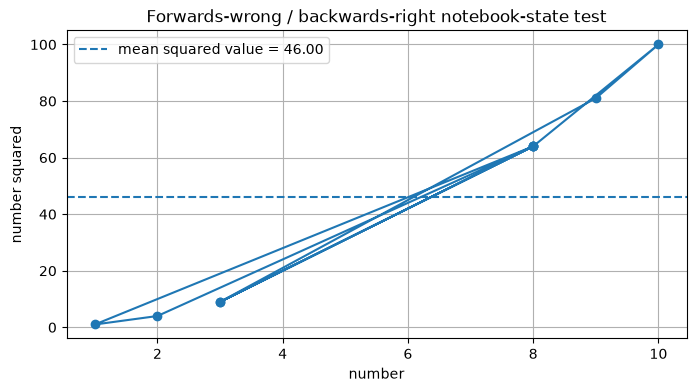

[DONE] Capture 000010: logged 4 artifact(s).


In [52]:
%%jupy_capture --label abc-second-pass-a
##done before# import matplotlib.plotly as plt
##  P.S. Cell A does not import matplotlib here, because Cell C
##+ will do it before we come back for the successful run of
##+ already did. Same for numpy.
##+ This is intentional notebook-state dependence for the A/B/C test.

avg_value = squared_numbers.mean()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    numbers,
    squared_numbers,
    marker="o",
)

ax.axhline(
    avg_value,
    linestyle="--",
    label=f"mean squared value = {avg_value:.2f}",
)

ax.set_title(
    "Forwards-wrong / backwards-right notebook-state test"
)
ax.set_xlabel("number")
ax.set_ylabel("number squared")
ax.grid(True)
ax.legend()

plot_path = (
    repo_root
    / "jupy_log"
    / "staging"
    / "abc_backwards_right.png"
)

plt.savefig(plot_path, dpi=150, bbox_inches="tight")
print("saved explicit plot file:", plot_path)
print("explicit plot exists:", plot_path.exists())

plt.show()

## 15. Code cell         27 — A, 1st execution: expected failure
#
## and
#
## 20. Code cell (still) 27 — A, 2nd execution: expected success and plot capture
##     call it Code Cell 27|43

In [53]:
## Code cell 28|44

dpypd.tree(f"{repo_root}/jupy_log")

+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md
        + 000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
        + 000003_1782480519781_2026-06-26T092839781-0400_capture-basic-input.py
        + 000004_1782480520093_2026-06-26T092840093-0400_capture-basic-stdout.txt
        + 000005_1782480662253_2026-06-26T093102253-0400_tee-basic-input.py
        + 000006_1782480662270_2026-06-26T093102270-0400_tee-basic-stdout.txt
        + 000007_1782480662281_2026-06-26T093102281-0400_tee-basic-display-01-01-text.txt
        + 000008_1782480744614_2026-06-26T093224614-0400_abc-state-reset-input.py
        + 000009_1782480744633_2026-06-26T093224633-0400_abc-state-reset-stdout.txt
        + 000010_1782481023043_2026-06-26T093703043-0400_abc-first-pass-a-input.py
        + 000011_1782481023504_2026-06-26T093703504-0400_abc-first-pass-a-exception.t

<hr/>

<span style="font-size:200%">Well, kamMA, I forgot 
    the `f` before the string in the<br/> 
    <code>dpypd.tree("{repo_root}/jupy_log")</code>
    <br/>line.</span>

What I'm saying is that it should have been as it stands
now, <code>dpypd.tree(f"{repo_root}/jupy_log")</code>.
We didn't run any MMJL on that code cell, so these
comments are the only record.

The first run's output was blank _and_ invalid,
    (though, again, we have no record... oh, except
    I can run a `%history` at the very end, with much
    output, that will elucidate things.) However, on
    this second run, it will put the `In` number 
    exactly ten more than the (hopefully-now-correct) 
    Code cell numbers from here on out,
    which should make errors in that area easy to 
    spot (from here on out; until I make another
    mistake ; )

<hr/>

In [55]:
# Code cell 29|45

print("JUST BECAUSE THIS WAS GOOD FOR DEBUGGING, I'M")
print("GOING TO FIND ANYTHING FROM THE PREVIOUS TRY")
print("AND FROM THIS TRY THAT HAVE TO DO WITH CELL A.")

import contextlib
import io

buffer = io.StringIO()  # string streamer

with contextlib.redirect_stdout(buffer):
    dpypd.tree(f"{repo_root}/jupy_log")
##endof:  with contextlib.redirect_stdout(buffer)

tree_out_str = buffer.getvalue()

grep_a_cell_results = [
    line
    for line in tree_out_str.splitlines()
    if r"abc-" in line and r"pass-a-" in line
]

print(*grep_a_cell_results, sep="\n")

JUST BECAUSE THIS WAS GOOD FOR DEBUGGING, I'M
GOING TO FIND ANYTHING FROM THE PREVIOUS TRY
AND FROM THIS TRY THAT HAVE TO DO WITH CELL A.
        + 000010_1782481023043_2026-06-26T093703043-0400_abc-first-pass-a-input.py
        + 000011_1782481023504_2026-06-26T093703504-0400_abc-first-pass-a-exception.txt
        + 000012_1782483189698_2026-06-26T101309698-0400_abc-first-pass-a-input.py
        + 000013_1782483189729_2026-06-26T101309729-0400_abc-first-pass-a-exception.txt
        + 000022_1782493617170_2026-06-26T130657170-0400_abc-second-pass-a-input.py
        + 000023_1782493618189_2026-06-26T130658189-0400_abc-second-pass-a-stdout.txt
        + 000024_1782493618203_2026-06-26T130658203-0400_abc-second-pass-a-display-01-01-text.txt
        + 000025_1782493618216_2026-06-26T130658216-0400_abc-second-pass-a-display-01-02-image.png


In [56]:
##  Code cell 30|46 — Manifest Check

display_banner()
show_manifest(limit=20)
display_banner()

-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 25

000006 | 000002 | stdout | text/plain | tee-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782480662270_2026-06-26T093102270-0400_tee-basic-stdout.txt
000007 | 000002 | display | text/plain | tee-basic-display-01-01-text | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1782480662281_2026-06-26T093102281-0400_tee-basic-display-01-01-text.txt
000008 | 000003 | input | text/x-python | abc-state-reset-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1782480744614_2026-06-26T093224614-0400_abc-state-reset-input.py
000009 | 000003 | stdout | text/plain | abc-state-reset-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1782480744633_2026-06-26T093224633-0400_abc-state-reset-stdout.txt
000010 | 000004 | input | text/x-py

<span style="font-size:150%; font-face:bold">MUST CHANGE (or at least
    check) <code>show_artifact</code> NUMBERS BELOW!</span>

########################################################################

-----------------------------------------------------------------
artifact_sequence: 000022
capture_sequence: 000010
role: input
label: abc-second-pass-a-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000022_1782493617170_2026-06-26T130657170-0400_abc-second-pass-a-input.py
exists: True

##done before# import matplotlib.plotly as plt
##  P.S. Cell A does not import matplotlib here, because Cell C
##+ will do it before we come back for the successful run of
##+ already did. Same for numpy.
##+ This is intentional notebook-state dependence for the A/B/C test.

avg_value = squared_numbers.mean()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    numbers,
    squared_numbers,
    marker="o",
)

ax.axhline(
    avg_value,
    linestyle="--",
    label=f"mean squared value = {avg_value:.2f}",
)

ax.set_title(
    "Forwards-wrong / backwards-right notebook-state test"


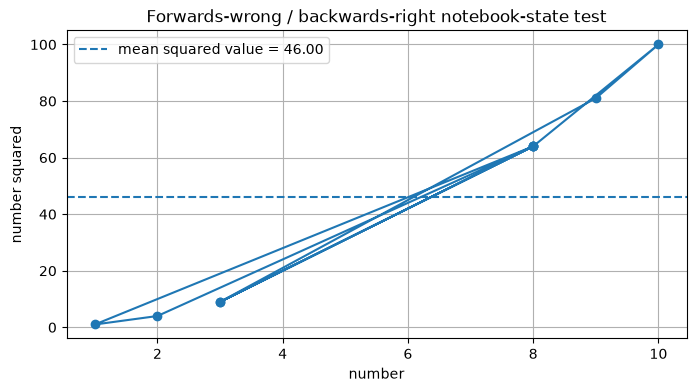

-----------------------------------------------------------------

I'm not going to output the binary image file. The
file directly above should let you know it exists.
(Hint: not on the first pass.)


########################################################################


In [57]:
##  Code cell 31|47, ANYTHING NEW?

########################################
##     REMEMBER TO MATCH NUMBERS!     ##
########################################

display_banner("#", 72)
print()
display_banner()
show_artifact(22)
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(23)
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(24)
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(25)
display_banner()
print()
print("I'm not going to output the binary image file. The")
print("file directly above should let you know it exists.")
print("(Hint: not on the first pass.)")
print(); print()
display_banner("#", 72)

<hr/>

<span style="font-size:200%">Hey, kamMA; there&apos;s
    some good news! ...</span>
    
... at least in this little news-bulletin Markdown
    cell. I had set things up so the figure does get
    displayed, so everyone can ignore that last banner
    of hyphens and the last three sentences of the 
    output directly above. Hooray!

<hr/>

---

**New stuff after Code cell (30 &amp;) 31, 
later for (46 &amp;) 47**

_Those all relate to **Cell A**_


**` Cell A     .`**<br/>
**` First try  .`**

<details>
<summary>Click the arrow to see the file contents for 
    Code cells 30 &amp; 31.
    Both related to <strong>Cell A</strong>.
    Note that any internal HTML should be escaped,
    and downward-pointing triangles should come
    before expanded <code>&lt;detail&gt;</code>,
    <code>&lt;summary&gt;</code> pairs.</summary>

<br/><hr/><br/>
**For Code cell 30 — Cell A related**

<pre>
-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 11

000001 |  | literal | text/markdown | details-summary-markdown-regression | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md
000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782480519781_2026-06-26T092839781-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782480520093_2026-06-26T092840093-0400_capture-basic-stdout.txt
000005 | 000002 | input | text/x-python | tee-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1782480662253_2026-06-26T093102253-0400_tee-basic-input.py
000006 | 000002 | stdout | text/plain | tee-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782480662270_2026-06-26T093102270-0400_tee-basic-stdout.txt
000007 | 000002 | display | text/plain | tee-basic-display-01-01-text | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1782480662281_2026-06-26T093102281-0400_tee-basic-display-01-01-text.txt
000008 | 000003 | input | text/x-python | abc-state-reset-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1782480744614_2026-06-26T093224614-0400_abc-state-reset-input.py
000009 | 000003 | stdout | text/plain | abc-state-reset-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1782480744633_2026-06-26T093224633-0400_abc-state-reset-stdout.txt
000010 | 000004 | input | text/x-python | abc-first-pass-a-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1782481023043_2026-06-26T093703043-0400_abc-first-pass-a-input.py
000011 | 000004 | exception | text/plain | abc-first-pass-a-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1782481023504_2026-06-26T093703504-0400_abc-first-pass-a-exception.txt
-----------------------------------------------------------------
</pre>

<br/><hr/><br/>
**For code cell 31 — Cell A related**

<pre>
########################################################################

-----------------------------------------------------------------
artifact_sequence: 000010
capture_sequence: 000004
role: input
label: abc-first-pass-a-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1782481023043_2026-06-26T093703043-0400_abc-first-pass-a-input.py
exists: True

##done before# import matplotlib.plotly as plt
##  P.S. Cell A does not import matplotlib here, because Cell C
##+ will do it before we come back for the successful run of
##+ already did. Same for numpy.
##+ This is intentional notebook-state dependence for the A/B/C test.

avg_value = squared_numbers.mean()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    numbers,
    squared_numbers,
    marker="o",
)

ax.axhline(
    avg_value,
    linestyle="--",
    label=f"mean squared value = {avg_value:.2f}",
)

ax.set_title(
    "Forwards-wrong / backwards-right notebook-state test"
)
ax.set_xlabel("number")
ax.set_ylabel("number squared")
ax.grid(True)
ax.legend()

plot_path = (
    repo_root
    / "jupy_log"
    / "staging"
    / "abc_backwards_right.png"
)

plt.savefig(plot_path, dpi=150, bbox_inches="tight")
print("saved explicit plot file:", plot_path)
print("explicit plot exists:", plot_path.exists())

plt.show()

## 15. Code cell         27 — A, 1st execution: expected failure
#
## and
#
## 20. Code cell (still) 27 — A, 2nd execution: expected success and plot capture
##     call it Code Cell 27|43

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000011
capture_sequence: 000004
role: exception
label: abc-first-pass-a-exception
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1782481023504_2026-06-26T093703504-0400_abc-first-pass-a-exception.txt
exists: True

Traceback (most recent call last):
  File "D:\David\my_repos_dwb\multimodal-jupy-logger\.venv_mmjl_test\Lib\site-packages\IPython\core\interactiveshell.py", line 3748, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\bball\AppData\Local\Temp\ipykernel_19472\2702192110.py", line 7, in &lt;module&gt;
    avg_value = squared_numbers.mean()
                ^^^^^^^^^^^^^^^
NameError: name 'squared_numbers' is not defined

-----------------------------------------------------------------

I'm not going to output the binary image file. The
file directly above should let you know it exists.
(Hint: not on the first pass.)


########################################################################
</pre>

</details>

<br/><hr/><br/>

**` Cell A     .`**<br/>
**` Second try .`**

<details>
<summary>Click the arrow to see the file contents for 
    Code cell <strike>28|<strong>39+x</strong> 
    28|<strong>43</strong> &mdash; THE <strong>Cell
    A</strong> second attempt.
    Note that any internal HTML should be escaped,
    and downward-pointing triangles should come
    before expanded <code>&lt;detail&gt;</code>,
    <code>&lt;summary&gt;</code> pairs.</summary>

**Note for Cell A (second), Code cell ~~39+x~~ 43**

_These observations are for the first time I ran the cell
and will probably not match the plot in this notebook._ -DWB

<div style="background-color: cyan; max-width: 750px; width: fit-content;">
<span style="font-family: monospace;">
<strong><em>
That plot has a very interesting way of showing that one degenerate<br/>
(repeated) <strike>, degenerate might not be the right word, eh 
kamMA?)</strike> value is 64<br/>
in <code style="background-color: cyan;">squared_numbers</code>, seen 
in the plot on the x-axis as 8 
in <code style="background-color: cyan;">numbers</code>.<br/>
One can see that more than two lines <em>come in</em>/<em>go out</em> at
(8, 64).<br/>
(9, 81) is another repeated value pair. The reason we don&apos;t 
see<br/>
the extra visits is simple.
</em></strong>
</span>

<div style="background-color: white"><br></div>

<details>
<summary>
<span style="font-family: monospace;">
<strong><em>Click to see the reason, 
if nested details/summary tags are allowed.</em></strong>
</span>
</summary>

<div style="background-color: white;">They are allowed!</div>
    

<div style="background-color: #FF8B00;">
The <code style="background-color: #FF8B00;">numbers</code> array is 
represented 
as <code style="background-color: #FF8B00;"
       >[8  2  8  6  8  9  9  5  3  10]</code>.

First of all, 9 goes from itself to itself in a connected scatter plot
(not the best choice of visualization in this situation, we will have
 to discuss that, kamMA.) The scatter plot makes things interesting in
another way; If we trace traversals between numbers, we can see that
several paths are traversed mutliple times. Let's walk the whole...
graph-like thingie, then order each path from small number to big,
then group our edge-like thingies.

<code style="background-color: #FF8B00;"
    >(8 → 2, 2 → 8, 8 → 6, 6 → 8, 8 → 9, 9 → 9, 9 → 5, 5 → 3, 3 → 10)</code>

each directed segment (-ish) becomes an edge (-ish) when one goes
<code style="background-color: #FF8B00;"
    >smaller ↔ same-or-larger</code> in every case.

<code style="background-color: #FF8B00;"
    >(2 ↔ 8, 2 ↔ 8, 6 ↔ 8, 6 ↔ 8, 8 ↔ 9, 9 ↔ 9, 5 ↔ 9, 3 ↔ 5, 3 ↔ 10)</code>

Now, we can order and group these, comparing firsts, and if the firsts
are the same, comparing seconds.

<code style="background-color: #FF8B00;"
    >(
  2↔8, 2↔8,  # Edge traversed twice
  3↔5,
  3↔10,
  5↔9,
  6↔8, 6↔8,  # Edge traversed twice
  8↔9,
  9↔9
)</code>

So we have two edges traversed twice. What an unnecessary but
interesting tangent. I was just trying to figure out how I could
analyze the distribution.
</div>
</div>

</details>

<br/>

<span style="font-family: monospace; background-color: cyan;"
    ><strong><em>Cyan for fun!!!</em></strong></span>

</details>

<br/><hr/><br/>

<details>
<summary>Click the arrow to see the file contents for 
    Code cells <strike>39+x+3 &amp; 
    39+x+4.</strike> 46 &amp; 47.
    All related to <strong>Cell A</strong>.
    Note that any internal HTML should be escaped,
    and downward-pointing triangles should come
    before expanded <code>&lt;detail&gt;</code>,
    <code>&lt;summary&gt;</code> pairs.</summary>
</summary>
    
**For Code cell ~~39+x+3~~ 46 — Cell A related** 

<pre>
-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 25

000006 | 000002 | stdout | text/plain | tee-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782480662270_2026-06-26T093102270-0400_tee-basic-stdout.txt
000007 | 000002 | display | text/plain | tee-basic-display-01-01-text | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1782480662281_2026-06-26T093102281-0400_tee-basic-display-01-01-text.txt
000008 | 000003 | input | text/x-python | abc-state-reset-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1782480744614_2026-06-26T093224614-0400_abc-state-reset-input.py
000009 | 000003 | stdout | text/plain | abc-state-reset-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1782480744633_2026-06-26T093224633-0400_abc-state-reset-stdout.txt
000010 | 000004 | input | text/x-python | abc-first-pass-a-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1782481023043_2026-06-26T093703043-0400_abc-first-pass-a-input.py
000011 | 000004 | exception | text/plain | abc-first-pass-a-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1782481023504_2026-06-26T093703504-0400_abc-first-pass-a-exception.txt
000012 | 000005 | input | text/x-python | abc-first-pass-a-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000012_1782483189698_2026-06-26T101309698-0400_abc-first-pass-a-input.py
000013 | 000005 | exception | text/plain | abc-first-pass-a-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000013_1782483189729_2026-06-26T101309729-0400_abc-first-pass-a-exception.txt
000014 | 000006 | input | text/x-python | abc-first-pass-b-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000014_1782485749975_2026-06-26T105549975-0400_abc-first-pass-b-input.py
000015 | 000006 | exception | text/plain | abc-first-pass-b-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000015_1782485750010_2026-06-26T105550010-0400_abc-first-pass-b-exception.txt
000016 | 000007 | input | text/x-python | abc-cell-c-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000016_1782487998909_2026-06-26T113318909-0400_abc-cell-c-input.py
000017 | 000007 | stdout | text/plain | abc-cell-c-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000017_1782487999540_2026-06-26T113319540-0400_abc-cell-c-stdout.txt
000018 | 000008 | input | text/x-python | abc-first-pass-b-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000018_1782489615139_2026-06-26T120015139-0400_abc-first-pass-b-input.py
000019 | 000008 | stdout | text/plain | abc-first-pass-b-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000019_1782489615444_2026-06-26T120015444-0400_abc-first-pass-b-stdout.txt
000020 | 000009 | input | text/x-python | abc-second-pass-b-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000020_1782491917505_2026-06-26T123837505-0400_abc-second-pass-b-input.py
000021 | 000009 | stdout | text/plain | abc-second-pass-b-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000021_1782491917526_2026-06-26T123837526-0400_abc-second-pass-b-stdout.txt
000022 | 000010 | input | text/x-python | abc-second-pass-a-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000022_1782493617170_2026-06-26T130657170-0400_abc-second-pass-a-input.py
000023 | 000010 | stdout | text/plain | abc-second-pass-a-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000023_1782493618189_2026-06-26T130658189-0400_abc-second-pass-a-stdout.txt
000024 | 000010 | display | text/plain | abc-second-pass-a-display-01-01-text | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000024_1782493618203_2026-06-26T130658203-0400_abc-second-pass-a-display-01-01-text.txt
000025 | 000010 | display | image/png | abc-second-pass-a-display-01-02-image | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000025_1782493618216_2026-06-26T130658216-0400_abc-second-pass-a-display-01-02-image.png
-----------------------------------------------------------------
</pre>

<br/><hr/><br/>
**For Code cell ~~39+x+4~~ 47 — Cell A related**

<pre>
########################################################################

-----------------------------------------------------------------
artifact_sequence: 000022
capture_sequence: 000010
role: input
label: abc-second-pass-a-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000022_1782493617170_2026-06-26T130657170-0400_abc-second-pass-a-input.py
exists: True

##done before# import matplotlib.plotly as plt
##  P.S. Cell A does not import matplotlib here, because Cell C
##+ will do it before we come back for the successful run of
##+ already did. Same for numpy.
##+ This is intentional notebook-state dependence for the A/B/C test.

avg_value = squared_numbers.mean()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    numbers,
    squared_numbers,
    marker="o",
)

ax.axhline(
    avg_value,
    linestyle="--",
    label=f"mean squared value = {avg_value:.2f}",
)

ax.set_title(
    "Forwards-wrong / backwards-right notebook-state test"
)
ax.set_xlabel("number")
ax.set_ylabel("number squared")
ax.grid(True)
ax.legend()

plot_path = (
    repo_root
    / "jupy_log"
    / "staging"
    / "abc_backwards_right.png"
)

plt.savefig(plot_path, dpi=150, bbox_inches="tight")
print("saved explicit plot file:", plot_path)
print("explicit plot exists:", plot_path.exists())

plt.show()

## 15. Code cell         27 — A, 1st execution: expected failure
#
## and
#
## 20. Code cell (still) 27 — A, 2nd execution: expected success and plot capture
##     call it Code Cell 27|43

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000023
capture_sequence: 000010
role: stdout
label: abc-second-pass-a-stdout
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000023_1782493618189_2026-06-26T130658189-0400_abc-second-pass-a-stdout.txt
exists: True

saved explicit plot file: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\staging\abc_backwards_right.png
explicit plot exists: True

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000024
capture_sequence: 000010
role: display
label: abc-second-pass-a-display-01-01-text
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000024_1782493618203_2026-06-26T130658203-0400_abc-second-pass-a-display-01-01-text.txt
exists: True

&lt;Figure size 800x400 with 1 Axes&gt;
-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000025
capture_sequence: 000010
role: display
label: abc-second-pass-a-display-01-02-image
mime: image/png
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000025_1782493618216_2026-06-26T130658216-0400_abc-second-pass-a-display-01-02-image.png
exists: True

&lt;note-from-the-editor&lt;
  The stuff from here on out is not actually true. I didn't
  realize that I&apos;d set things up for the image to be 
  outputted on the second run. So I&apos;m going to make fake
  HTML comments to highlight that the following part is 
  incorrect.<br/>
  It is true that we only get
    
        &lt;Figure size 800x400 with 1 Axes&gt;
  
  for this output, which is a copy/paste of the output from
  Code cell (31|)<strong>47</strong>. But in the Jupyter 
  notebook output for <strong>47</strong>, the
  image of the captured figure is visible for all to see!
&lt;/note-from-the-editor&gt;

&lt;!-- What&apos;s in these pseudo comments is not true! Hooray!

-----------------------------------------------------------------

I'm not going to output the binary image file. The
file directly above should let you know it exists.
(Hint: not on the first pass.)

  --&gt;


########################################################################
</pre>

</details>

<hr/>

---

<span style="font-size: 150%; font-face: bold;">You 
can skip the next stuff (to the crossed out 
<code>h2</code>, the <strong>## 19</strong>,) where
your first code cell will be Code cell 48, 
<strong>if you've done B and A twice</strong>. 
Otherwise, keep going down with 
Cell B, which is Code cell 32.</span>

---

---

**If you have finished A, B, C, then back to B, A**

**It's time to go to Code cell 39+x+4+1=48**, a.k.a. 
Code cell Z, where $Z=48$ (because $x=4$) which is 
is after **\## 19**, the crossed out `h2`.

Links never seem to work. Scrolling time.

Unless you haven't done A twice, in which case you
can just go on to the next cell.

---

---

**`=============`**<br/>
**`Cell B, below`**<br/>
**`=============`**<br/>
- For **16**
  (`Code cell         32 — first execution: expected failure`).
  This output is for cells **below** this Markdown cell.

  - Expected result:

```text
NameError involving squared_numbers
```

  - The capture should still log:
    * the input
    * the exception
    * any output produced before the exception, if present
  - _All this output comes from Code cells **below** this Markdown cell._
  - ACTUAL OUTPUT:

```text
---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[34], line 1
----> 1 squared_numbers = numbers ** 2
      2 
      3 print("squared_numbers:", squared_numbers)
      4 

NameError: name 'numbers' is not defined
[DONE] Capture 000006: logged 2 artifact(s).
[MMJL] %%jupy_capture captured an execution error.
```

  - (Output again)
    - This time, with exception text (in the Jupyter notebook,
      the text with a red background) bolded (immediately
      below.) The dots anchoring and aligning the right side 
      weren't part of original output, nor of any following 
      output in which they appear.

**`---------------------------------------------------------------------------            .`**<br/>
**`NameError                                 Traceback (most recent call last)            .`**<br/>
**`Cell In[34], line 1                                                                    .`**<br/>
**`----> 1 squared_numbers = numbers ** 2                                                 .`**<br/>
**`      2                                                                                .`**<br/>
**`      3 print("squared_numbers:", squared_numbers)                                     .`**<br/>
**`      4                                                                                .`**<br/>
**`                                                                                       .`**<br/>
**`NameError: name 'numbers' is not defined                                               .`**<br/>
`[DONE] Capture 000006: logged 2 artifact(s).                                           .`<br/>
**`[MMJL] %%jupy_capture captured an execution error.                                     .`**

  - Output of `dpypd.tree()`

```text
+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md
        + 000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
        + 000003_1782480519781_2026-06-26T092839781-0400_capture-basic-input.py
        + 000004_1782480520093_2026-06-26T092840093-0400_capture-basic-stdout.txt
        + 000005_1782480662253_2026-06-26T093102253-0400_tee-basic-input.py
        + 000006_1782480662270_2026-06-26T093102270-0400_tee-basic-stdout.txt
        + 000007_1782480662281_2026-06-26T093102281-0400_tee-basic-display-01-01-text.txt
        + 000008_1782480744614_2026-06-26T093224614-0400_abc-state-reset-input.py
        + 000009_1782480744633_2026-06-26T093224633-0400_abc-state-reset-stdout.txt
        + 000010_1782481023043_2026-06-26T093703043-0400_abc-first-pass-a-input.py
        + 000011_1782481023504_2026-06-26T093703504-0400_abc-first-pass-a-exception.txt
        + 000012_1782483189698_2026-06-26T101309698-0400_abc-first-pass-a-input.py
        + 000013_1782483189729_2026-06-26T101309729-0400_abc-first-pass-a-exception.txt
        + 000014_1782485749975_2026-06-26T105549975-0400_abc-first-pass-b-input.py
        + 000015_1782485750010_2026-06-26T105550010-0400_abc-first-pass-b-exception.txt
    + manifest.tsv
    + staging/
    + timelines/
```

  - All content of `manifest.tsv`

```text
artifact_sequence	capture_sequence	timestamp	kind	mime	role	label	path
000001		1782480093619_2026-06-26T092133619-0400	text	text/markdown	literal	details-summary-markdown-regression	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md
000002		1782480116471_2026-06-26T092156471-0400	html	text/html	literal	details-summary-html-control	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
000003	000001	1782480519781_2026-06-26T092839781-0400	text	text/x-python	input	capture-basic-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782480519781_2026-06-26T092839781-0400_capture-basic-input.py
000004	000001	1782480520093_2026-06-26T092840093-0400	text	text/plain	stdout	capture-basic-stdout	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782480520093_2026-06-26T092840093-0400_capture-basic-stdout.txt
000005	000002	1782480662253_2026-06-26T093102253-0400	text	text/x-python	input	tee-basic-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1782480662253_2026-06-26T093102253-0400_tee-basic-input.py
000006	000002	1782480662270_2026-06-26T093102270-0400	text	text/plain	stdout	tee-basic-stdout	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782480662270_2026-06-26T093102270-0400_tee-basic-stdout.txt
000007	000002	1782480662281_2026-06-26T093102281-0400	text	text/plain	display	tee-basic-display-01-01-text	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1782480662281_2026-06-26T093102281-0400_tee-basic-display-01-01-text.txt
000008	000003	1782480744614_2026-06-26T093224614-0400	text	text/x-python	input	abc-state-reset-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1782480744614_2026-06-26T093224614-0400_abc-state-reset-input.py
000009	000003	1782480744633_2026-06-26T093224633-0400	text	text/plain	stdout	abc-state-reset-stdout	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1782480744633_2026-06-26T093224633-0400_abc-state-reset-stdout.txt
000010	000004	1782481023043_2026-06-26T093703043-0400	text	text/x-python	input	abc-first-pass-a-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1782481023043_2026-06-26T093703043-0400_abc-first-pass-a-input.py
000011	000004	1782481023504_2026-06-26T093703504-0400	text	text/plain	exception	abc-first-pass-a-exception	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1782481023504_2026-06-26T093703504-0400_abc-first-pass-a-exception.txt
000012	000005	1782483189698_2026-06-26T101309698-0400	text	text/x-python	input	abc-first-pass-a-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000012_1782483189698_2026-06-26T101309698-0400_abc-first-pass-a-input.py
000013	000005	1782483189729_2026-06-26T101309729-0400	text	text/plain	exception	abc-first-pass-a-exception	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000013_1782483189729_2026-06-26T101309729-0400_abc-first-pass-a-exception.txt
000014	000006	1782485749975_2026-06-26T105549975-0400	text	text/x-python	input	abc-first-pass-b-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000014_1782485749975_2026-06-26T105549975-0400_abc-first-pass-b-input.py
000015	000006	1782485750010_2026-06-26T105550010-0400	text	text/plain	exception	abc-first-pass-b-exception	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000015_1782485750010_2026-06-26T105550010-0400_abc-first-pass-b-exception.txt

```

  - Content of `_abc-first-pass-b-input.py` input text (code)

```python
squared_numbers = numbers ** 2

print("squared_numbers:", squared_numbers)

## 16. Code cell         32 — B, first execution: expected failure
#
## and
#
## 18. Code cell (still) 32 — B, second execution: expected success
##     call it Code cell 32|40

```

  - Content of `_abc-first-pass-b-exception.txt` output text (exception)

```text
Traceback (most recent call last):
  File "D:\David\my_repos_dwb\multimodal-jupy-logger\.venv_mmjl_test\Lib\site-packages\IPython\core\interactiveshell.py", line 3748, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\bball\AppData\Local\Temp\ipykernel_19472\2522802886.py", line 1, in <module>
    squared_numbers = numbers ** 2
                      ^^^^^^^
NameError: name 'numbers' is not defined. Did you forget to import 'numbers'?

```

<br/>

Take note that the code file matches the code cell exactly,

<span style="font-size:175%">but, <strong>kamMA</strong>, just
as in the first, failed Cell A, the
exception text shown on the screen in the Jupyter
notebook <strong>does not</strong> match the text in the
exception logging file.</span>

<span style="font-size:125%">Interestingly, though the vital 
information matches, there is an interesting (but ultimately
unhelpful) hint that
appears in the logged exception versus the on-screen
exception. Once again, this section will probably be 
expanded with a _What I learned about Jupyter_ 
section.</span>

`---`

**What I learned about Jupyter from Cell B's failure**

---

**` Cell B     `**
**` Second try `**

- For **18** (`Code cell (still) 32 — second execution: expected success`)
- This would be code cell 32+y=40, (y=8) so I'm going to call it ~~**32|32+y**~~ **32|40**
  - The only difference in the input is the change,
    - from:
      - `%%jupy_capture --label abc-first-pass-b`
    - to:
      - `%%jupy_capture --label abc-second-pass-b`
  
  - ACTUAL OUTPUT
 
```text
blah
```

The rest of the successful run's files' contents can be seen in the output of Code cells ~~**32+y+2** (with 34|**32+y+2**) and **32+y+3** (with 35|**32+y+3**)~~ **42** (with 34|**42**) and **43** (with 35|**43**)

<hr/>

<span style="font-size:200%">Note, kamMA, that I accidentally
    re-ran Code cell 27 after running Code cell 31.</span>

I imagine that this will add something extra to the manifest
as well as messing up the match between the Code cell number
and the execution number (`In`/`Out` number.)

<hr/>

In [47]:
%%jupy_capture --label abc-second-pass-b
squared_numbers = numbers ** 2

print("squared_numbers:", squared_numbers)

## 16. Code cell         32 — B, first execution: expected failure
#
## and
#
## 18. Code cell (still) 32 — B, second execution: expected success
##     call it Code cell 32|40

squared_numbers: [ 64   1   4  64   9  64   9  81 100  64]
[DONE] Capture 000009: logged 2 artifact(s).


<hr/>

<span style="font-size:200%">Note, kamMA, that 
    I accidentally</span><br/><br/>
<span style="font-size:125%">
    ran <strong>Cell B</strong> (as 
    <code>In</code> number <code>[42]:</code>) 
    before changing the <code>--label</code>&apos;s 
    value string's &apos;<code>first</code>&apos; to 
    &apos;<code>second</code>&apos; and then re-ran 
    Code cell 33|<strong>41</strong> and apparently 
    a few others (because (33|)<strong>41</strong> 
    went through 
    as <code>In</code> number <code>[46]:</code>.) 
    The <code>manifest.tsv</code> and 
    the <code>dpypd.tree</code> output will 
    give us more details.</span>

So, again, I've added something extra to the manifest
as well as messing up the match between the Code cell number
and the execution number (`In`/`Out` number.)

Though, apparently, as I just copied and pasted from the
previous Dave's-mistake error — in the Markdown cell 
immediately above the Code cell immediately above _this_
cell — I keep my problems local in space, if not in time.

<span style="font-size:125%">So, kamMA, the last cell that
was run correctly was Code cell 49 (the follow-up on
<strong>Cell C</strong>, and I will therefore start
from <strong>Cell B</strong>, being Code 
cell (32|)<strong>40</strong>.</span>

<hr/>

In [48]:
## Code cell 33|41

dpypd.tree(f"{repo_root}/jupy_log")

+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md
        + 000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
        + 000003_1782480519781_2026-06-26T092839781-0400_capture-basic-input.py
        + 000004_1782480520093_2026-06-26T092840093-0400_capture-basic-stdout.txt
        + 000005_1782480662253_2026-06-26T093102253-0400_tee-basic-input.py
        + 000006_1782480662270_2026-06-26T093102270-0400_tee-basic-stdout.txt
        + 000007_1782480662281_2026-06-26T093102281-0400_tee-basic-display-01-01-text.txt
        + 000008_1782480744614_2026-06-26T093224614-0400_abc-state-reset-input.py
        + 000009_1782480744633_2026-06-26T093224633-0400_abc-state-reset-stdout.txt
        + 000010_1782481023043_2026-06-26T093703043-0400_abc-first-pass-a-input.py
        + 000011_1782481023504_2026-06-26T093703504-0400_abc-first-pass-a-exception.t

<hr/>

<span style="font-size:200%">kamMA, <strike>we&apos;ll 
    have another extra bit of logging for the exception 
    I just got.</strike></span>

I had "fixed" the code with <code>"f{repo_root}/jupy_log"</code> 
instead of </code>f"{repo_root}/jupy_log"</code>. 
~~It will be inspected below!~~ Oh yeah, I hadn't put any 
logging directive (magic) in the cell that got the exception.

<span style="font-size:150%">kamMA, you will, however, probably 
    want to notice that artifacts 12 and 13 have the same names 
    as artifacts 10 and 11.</span>
    
I'm just going to assume they have the same content without 
checking. ERP wins again!

<hr/>

<hr/>

<span style="font-size:175%">kamMA, in the previous output
    and the next look at the manifest, numbers 18 and 19
    are from my mistake of 
    running <strong>Cell B</strong> the second time without
    changing the <code>--label</code> value.</span>

<hr/>

In [49]:
##  Code cell 34|42 — Manifest Check

display_banner()
show_manifest(limit=20)
display_banner()

-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 21

000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782480519781_2026-06-26T092839781-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782480520093_2026-06-26T092840093-0400_capture-basic-stdout.txt
000005 | 000002 | input | text/x-python | tee-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1782480662253_2026-06-26T093102253-0400_tee-basic-input.py
000006 | 000002 | stdout | text/plain | tee-basic-

<span style="font-size:150%; font-face:bold">MUST CHANGE (or at least
    check) <code>show_artifact</code> NUMBERS BELOW!</span>

In [51]:
##  Code cell 35|43, ANYTHING NEW?

########################################
##     REMEMBER TO MATCH NUMBERS!     ##
########################################

display_banner("#", 72)
print()
display_banner()
show_artifact(20)
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(21)
display_banner()
print(); print()
display_banner("#", 72)

########################################################################

-----------------------------------------------------------------
artifact_sequence: 000020
capture_sequence: 000009
role: input
label: abc-second-pass-b-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000020_1782491917505_2026-06-26T123837505-0400_abc-second-pass-b-input.py
exists: True

squared_numbers = numbers ** 2

print("squared_numbers:", squared_numbers)

## 16. Code cell         32 — B, first execution: expected failure
#
## and
#
## 18. Code cell (still) 32 — B, second execution: expected success
##     call it Code cell 32|40

-----------------------------------------------------------------

-----------------------------------------------------------------
artifact_sequence: 000021
capture_sequence: 000009
role: stdout
label: abc-second-pass-b-stdout
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000021_17824919175

<hr/>

Well, we might as well mess up all at once.

<span style="font-size=175%">kamMA, I re-ran it with old values 
    maybe once, maybe twice; possible 15 & 16 manifest monotonic 
    numbers for one or both, possibly 18 & 19 manifest monotonic 
    number.Once again, the manifest will help us 
    know, and we can compare file contents if desired. Eventually,
    our timeline will make it easy to figure stuff out, or at least
    to figure out the stuff that we use MMJL on.<br/>I'm going up
    to run the previous code cell with the 
    correct <code>20</code> and <code>21</code> for 
    the calls to `show_artifact`.</span>

---

**New stuff after Code cell (34 &amp; ) 35, later for (43 &amp;) 44**

_Those all relate to **Cell B**_

<details>

<summary>Click the arrow to see the file contents for 
    Code cells (35 &amp; 36) then <strike>( 33+y+2 &amp; 33+y+3
    )</strike>. 43 &amp; 44
    All related to <strong>Cell B</strong>.
    Note that any internal HTML should be escaped,
    and downward-pointing triangles should come
    before expanded <code>&lt;detail&gt;</code>,
    <code>&lt;summary&gt;</code> pairs.</summary>

<br/><hr/><br/>
**For Code cell 34 — Cell B related**

<pre>
-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 15

000001 |  | literal | text/markdown | details-summary-markdown-regression | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md
000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782480519781_2026-06-26T092839781-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782480520093_2026-06-26T092840093-0400_capture-basic-stdout.txt
000005 | 000002 | input | text/x-python | tee-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1782480662253_2026-06-26T093102253-0400_tee-basic-input.py
000006 | 000002 | stdout | text/plain | tee-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782480662270_2026-06-26T093102270-0400_tee-basic-stdout.txt
000007 | 000002 | display | text/plain | tee-basic-display-01-01-text | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1782480662281_2026-06-26T093102281-0400_tee-basic-display-01-01-text.txt
000008 | 000003 | input | text/x-python | abc-state-reset-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1782480744614_2026-06-26T093224614-0400_abc-state-reset-input.py
000009 | 000003 | stdout | text/plain | abc-state-reset-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1782480744633_2026-06-26T093224633-0400_abc-state-reset-stdout.txt
000010 | 000004 | input | text/x-python | abc-first-pass-a-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1782481023043_2026-06-26T093703043-0400_abc-first-pass-a-input.py
000011 | 000004 | exception | text/plain | abc-first-pass-a-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1782481023504_2026-06-26T093703504-0400_abc-first-pass-a-exception.txt
000012 | 000005 | input | text/x-python | abc-first-pass-a-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000012_1782483189698_2026-06-26T101309698-0400_abc-first-pass-a-input.py
000013 | 000005 | exception | text/plain | abc-first-pass-a-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000013_1782483189729_2026-06-26T101309729-0400_abc-first-pass-a-exception.txt
000014 | 000006 | input | text/x-python | abc-first-pass-b-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000014_1782485749975_2026-06-26T105549975-0400_abc-first-pass-b-input.py
000015 | 000006 | exception | text/plain | abc-first-pass-b-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000015_1782485750010_2026-06-26T105550010-0400_abc-first-pass-b-exception.txt
-----------------------------------------------------------------
</pre>

<br/><hr/><br/>
**For Code cell 35 — Cell B related**

<pre>
########################################################################

-----------------------------------------------------------------
artifact_sequence: 000014
capture_sequence: 000006
role: input
label: abc-first-pass-b-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000014_1782485749975_2026-06-26T105549975-0400_abc-first-pass-b-input.py
exists: True

squared_numbers = numbers ** 2

print("squared_numbers:", squared_numbers)

## 16. Code cell         32 — B, first execution: expected failure
#
## and
#
## 18. Code cell (still) 32 — B, second execution: expected success
##     call it Code cell 32|40

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000015
capture_sequence: 000006
role: exception
label: abc-first-pass-b-exception
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000015_1782485750010_2026-06-26T105550010-0400_abc-first-pass-b-exception.txt
exists: True

Traceback (most recent call last):
  File "D:\David\my_repos_dwb\multimodal-jupy-logger\.venv_mmjl_test\Lib\site-packages\IPython\core\interactiveshell.py", line 3748, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\bball\AppData\Local\Temp\ipykernel_19472\2522802886.py", line 1, in &lt;module&gt;
    squared_numbers = numbers ** 2
                      ^^^^^^^
NameError: name 'numbers' is not defined. Did you forget to import 'numbers'?

-----------------------------------------------------------------


########################################################################
</pre>

<br/><hr/><br/>

**` Cell B     `**
**` Second try `**

**For Code cell ~~33+y+2~~ 43 — Cell B related**

```text
-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 21

000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782480519781_2026-06-26T092839781-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782480520093_2026-06-26T092840093-0400_capture-basic-stdout.txt
000005 | 000002 | input | text/x-python | tee-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1782480662253_2026-06-26T093102253-0400_tee-basic-input.py
000006 | 000002 | stdout | text/plain | tee-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782480662270_2026-06-26T093102270-0400_tee-basic-stdout.txt
000007 | 000002 | display | text/plain | tee-basic-display-01-01-text | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1782480662281_2026-06-26T093102281-0400_tee-basic-display-01-01-text.txt
000008 | 000003 | input | text/x-python | abc-state-reset-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1782480744614_2026-06-26T093224614-0400_abc-state-reset-input.py
000009 | 000003 | stdout | text/plain | abc-state-reset-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1782480744633_2026-06-26T093224633-0400_abc-state-reset-stdout.txt
000010 | 000004 | input | text/x-python | abc-first-pass-a-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1782481023043_2026-06-26T093703043-0400_abc-first-pass-a-input.py
000011 | 000004 | exception | text/plain | abc-first-pass-a-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1782481023504_2026-06-26T093703504-0400_abc-first-pass-a-exception.txt
000012 | 000005 | input | text/x-python | abc-first-pass-a-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000012_1782483189698_2026-06-26T101309698-0400_abc-first-pass-a-input.py
000013 | 000005 | exception | text/plain | abc-first-pass-a-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000013_1782483189729_2026-06-26T101309729-0400_abc-first-pass-a-exception.txt
000014 | 000006 | input | text/x-python | abc-first-pass-b-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000014_1782485749975_2026-06-26T105549975-0400_abc-first-pass-b-input.py
000015 | 000006 | exception | text/plain | abc-first-pass-b-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000015_1782485750010_2026-06-26T105550010-0400_abc-first-pass-b-exception.txt
000016 | 000007 | input | text/x-python | abc-cell-c-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000016_1782487998909_2026-06-26T113318909-0400_abc-cell-c-input.py
000017 | 000007 | stdout | text/plain | abc-cell-c-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000017_1782487999540_2026-06-26T113319540-0400_abc-cell-c-stdout.txt
000018 | 000008 | input | text/x-python | abc-first-pass-b-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000018_1782489615139_2026-06-26T120015139-0400_abc-first-pass-b-input.py
000019 | 000008 | stdout | text/plain | abc-first-pass-b-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000019_1782489615444_2026-06-26T120015444-0400_abc-first-pass-b-stdout.txt
000020 | 000009 | input | text/x-python | abc-second-pass-b-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000020_1782491917505_2026-06-26T123837505-0400_abc-second-pass-b-input.py
000021 | 000009 | stdout | text/plain | abc-second-pass-b-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000021_1782491917526_2026-06-26T123837526-0400_abc-second-pass-b-stdout.txt
-----------------------------------------------------------------
```

<br/><hr/><br/>
**For Code cell ~~33+x+3~~ 44 — Cell B related**

```text
########################################################################

-----------------------------------------------------------------
artifact_sequence: 000020
capture_sequence: 000009
role: input
label: abc-second-pass-b-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000020_1782491917505_2026-06-26T123837505-0400_abc-second-pass-b-input.py
exists: True

squared_numbers = numbers ** 2

print("squared_numbers:", squared_numbers)

## 16. Code cell         32 — B, first execution: expected failure
#
## and
#
## 18. Code cell (still) 32 — B, second execution: expected success
##     call it Code cell 32|40

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000021
capture_sequence: 000009
role: stdout
label: abc-second-pass-b-stdout
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000021_1782491917526_2026-06-26T123837526-0400_abc-second-pass-b-stdout.txt
exists: True

squared_numbers: [ 64   1   4  64   9  64   9  81 100  64]

-----------------------------------------------------------------


########################################################################
```

</details>

<hr/>

---

<span style="font-size: 150%; font-face: bold;">If this has been your 
second time doing B, go back to A (Code cell 
28|<strong>45</strong>).</span>

And while you're having a look at Code cell (28|)**45**, don't 
forget to look at the Markdown above, which
details the change you make to the value handed the
<code>--label</code> option, and

<span style="font-size:150%">that change is to go from
the old<br/><code>--label abc-first-pass-a</code><br/>to the 
new<br/><code>--label abc-second-pass-a</code></span>,

Then, after finishing B and the following cells, you'll go
to A again (you'll be told where to go after finishing B.)

<span style="font-size:150%">If it is your first time doing 
the **Cell B** stuff, go ahead and continue down.</span>

---

**`=============`**<br/>
**`Cell C, below`**<br/>
**`=============`**<br/>
- For **17** (`Code cell 36 — C: expected success`)

  - Expected result:
    - Success. 
  - File contents for successful run
    - Look at the output of **Code cells 38-39**
  - ACTUAL OUTPUT

```text
foo
```

In [38]:
%%jupy_capture --label abc-cell-c
import numpy as np
import matplotlib.pyplot as plt

## Older global-random-state style, like MLU
# numbers = np.random.randint(1, 11, size=10)

rng = np.random.default_rng()
numbers = rng.integers(1, 11, size=10)

print("numbers:", numbers)

## 17. Code cell 36 — C: expected success

numbers: [ 8  1  2  8  3  8  3  9 10  8]
[DONE] Capture 000007: logged 2 artifact(s).


In [39]:
## Code cell 37

dpypd.tree("f{repo_root}/jupy_log")

+ D:\David\my_repos_dwb\multimodal-jupy-logger\f{repo_root}\jupy_log


In [40]:
##  Code cell 38 — Manifest check

display_banner()
show_manifest(limit=20)
display_banner()

-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 17

000001 |  | literal | text/markdown | details-summary-markdown-regression | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md
000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782480519781_2026-06-26T092839781-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782480520093_2026-06-26T092840093-0400_capture-basic-stdout.txt
000005 | 00000

<span style="font-size:150%; font-face:bold">MUST CHANGE (or at least
    check) <code>show_artifact</code> NUMBERS BELOW!</span>

In [41]:
##  Code cell 39 — ANYTHING NEW?

display_banner("#", 72)
print()
display_banner()
show_artifact(16)
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(17)
display_banner()
print(); print()
display_banner("#", 72)

########################################################################

-----------------------------------------------------------------
artifact_sequence: 000016
capture_sequence: 000007
role: input
label: abc-cell-c-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000016_1782487998909_2026-06-26T113318909-0400_abc-cell-c-input.py
exists: True

import numpy as np
import matplotlib.pyplot as plt

## Older global-random-state style, like MLU
# numbers = np.random.randint(1, 11, size=10)

rng = np.random.default_rng()
numbers = rng.integers(1, 11, size=10)

print("numbers:", numbers)

## 17. Code cell 36 — C: expected success

-----------------------------------------------------------------

-----------------------------------------------------------------
artifact_sequence: 000017
capture_sequence: 000007
role: stdout
label: abc-cell-c-stdout
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000017_1

---

**New stuff after Code cell 39**

<details>
<summary>Click the right-pointing triangle to see 
    the file contents. 
    Note that any internal HTML should be escaped,
    and downward-pointing triangles should come
    before expanded <code>&lt;detail&gt;</code>,
    <code>&lt;summary&gt;</code> pairs.</summary>

<br/><hr/><br/>
**For Code cell 38 (Manifest check) — Cell C related**

<pre>
-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 17

000001 |  | literal | text/markdown | details-summary-markdown-regression | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md
000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782480519781_2026-06-26T092839781-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782480520093_2026-06-26T092840093-0400_capture-basic-stdout.txt
000005 | 000002 | input | text/x-python | tee-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1782480662253_2026-06-26T093102253-0400_tee-basic-input.py
000006 | 000002 | stdout | text/plain | tee-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782480662270_2026-06-26T093102270-0400_tee-basic-stdout.txt
000007 | 000002 | display | text/plain | tee-basic-display-01-01-text | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1782480662281_2026-06-26T093102281-0400_tee-basic-display-01-01-text.txt
000008 | 000003 | input | text/x-python | abc-state-reset-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1782480744614_2026-06-26T093224614-0400_abc-state-reset-input.py
000009 | 000003 | stdout | text/plain | abc-state-reset-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1782480744633_2026-06-26T093224633-0400_abc-state-reset-stdout.txt
000010 | 000004 | input | text/x-python | abc-first-pass-a-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1782481023043_2026-06-26T093703043-0400_abc-first-pass-a-input.py
000011 | 000004 | exception | text/plain | abc-first-pass-a-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1782481023504_2026-06-26T093703504-0400_abc-first-pass-a-exception.txt
000012 | 000005 | input | text/x-python | abc-first-pass-a-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000012_1782483189698_2026-06-26T101309698-0400_abc-first-pass-a-input.py
000013 | 000005 | exception | text/plain | abc-first-pass-a-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000013_1782483189729_2026-06-26T101309729-0400_abc-first-pass-a-exception.txt
000014 | 000006 | input | text/x-python | abc-first-pass-b-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000014_1782485749975_2026-06-26T105549975-0400_abc-first-pass-b-input.py
000015 | 000006 | exception | text/plain | abc-first-pass-b-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000015_1782485750010_2026-06-26T105550010-0400_abc-first-pass-b-exception.txt
000016 | 000007 | input | text/x-python | abc-cell-c-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000016_1782487998909_2026-06-26T113318909-0400_abc-cell-c-input.py
000017 | 000007 | stdout | text/plain | abc-cell-c-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000017_1782487999540_2026-06-26T113319540-0400_abc-cell-c-stdout.txt
-----------------------------------------------------------------
</pre>

<br/><hr/><br/>
**For Code cell 39 (Looking at artifacts) — Cell C related**

<pre>
########################################################################

-----------------------------------------------------------------
artifact_sequence: 000016
capture_sequence: 000007
role: input
label: abc-cell-c-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000016_1782487998909_2026-06-26T113318909-0400_abc-cell-c-input.py
exists: True

import numpy as np
import matplotlib.pyplot as plt

## Older global-random-state style, like MLU
# numbers = np.random.randint(1, 11, size=10)

rng = np.random.default_rng()
numbers = rng.integers(1, 11, size=10)

print("numbers:", numbers)

## 17. Code cell 36 — C: expected success

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000017
capture_sequence: 000007
role: stdout
label: abc-cell-c-stdout
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000017_1782487999540_2026-06-26T113319540-0400_abc-cell-c-stdout.txt
exists: True

numbers: [ 8  1  2  8  3  8  3  9 10  8]

-----------------------------------------------------------------


########################################################################
</pre>

</details>

---

<span style="font-size: 150%; font-face: bold;">If you 
haven't done B (and A) twice, go up and do B (Code cell 
32|<strong>40</strong>.)</span>

And while you're having a look at Code cell 32|**40**, 
don't forget to look at the Markdown above, which
details the change you make to the value handed the
<code>--label</code> option, and

<span style="font-size:150%">that change is to go from
the old<br/><code>--label abc-first-pass-b</code><br/>to the 
new<br/><code>--label abc-second-pass-b</code></span>,

Then, after finishing B and the following cells, you'll go
to A again (you'll be told where to go after finishing B.)

---

---

(**18** combined with **16** — both are Cell B) See above

---



## 19.~~Code cell~~ — ~~configure Matplotlib inline rendering~~ 

#### Note: trying (later: tried and succeeded) to do this earlier, in **13.1**

~~Run this before the successful A cell.~~

~~\`\`\``python`~~<br/>
~~`%matplotlib inline`~~<br/>
~~\`\`\`~~

---

---

(**20** combined with **16** — both are Cell A) See above

---

---

<span style="font-size: 150%; font-face: bold;">If you 
have done the whole A, B, C, then back for B and A, go ahead and
continue. Code cell Z will be your first to do, now. The last
one you should have completed was <strike>(31|)**39+x+4**</strike> 
but x=4, so the last one should have been 31|**47**, and 
40+x+4=Z-1, so we go to Code cell Z=48 </span>

---

---

_For **15**&ndash;**20**, looking towards **21**_

This tests two related but distinct things:

* inline PNG capture by `%%jupy_capture`
* creation of a file that `%jupy_file` can log explicitly

In [58]:
## Code cell Z = 40+x+5 | _{x=4} => Code cell 48

dpypd.tree(f"{repo_root}/jupy_log")

+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md
        + 000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
        + 000003_1782480519781_2026-06-26T092839781-0400_capture-basic-input.py
        + 000004_1782480520093_2026-06-26T092840093-0400_capture-basic-stdout.txt
        + 000005_1782480662253_2026-06-26T093102253-0400_tee-basic-input.py
        + 000006_1782480662270_2026-06-26T093102270-0400_tee-basic-stdout.txt
        + 000007_1782480662281_2026-06-26T093102281-0400_tee-basic-display-01-01-text.txt
        + 000008_1782480744614_2026-06-26T093224614-0400_abc-state-reset-input.py
        + 000009_1782480744633_2026-06-26T093224633-0400_abc-state-reset-stdout.txt
        + 000010_1782481023043_2026-06-26T093703043-0400_abc-first-pass-a-input.py
        + 000011_1782481023504_2026-06-26T093703504-0400_abc-first-pass-a-exception.t

In [59]:
##  Code cell 49 — Manifest check

display_banner()
show_manifest(limit=20)
display_banner()

-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 25

000006 | 000002 | stdout | text/plain | tee-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782480662270_2026-06-26T093102270-0400_tee-basic-stdout.txt
000007 | 000002 | display | text/plain | tee-basic-display-01-01-text | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1782480662281_2026-06-26T093102281-0400_tee-basic-display-01-01-text.txt
000008 | 000003 | input | text/x-python | abc-state-reset-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1782480744614_2026-06-26T093224614-0400_abc-state-reset-input.py
000009 | 000003 | stdout | text/plain | abc-state-reset-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1782480744633_2026-06-26T093224633-0400_abc-state-reset-stdout.txt
000010 | 000004 | input | text/x-py

<span style="font-size:150%; font-face:bold">MUST CHANGE (or at least
    check) <code>show_artifact</code> NUMBERS BELOW!</span>

########################################################################

-----------------------------------------------------------------
artifact_sequence: 000022
capture_sequence: 000010
role: input
label: abc-second-pass-a-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000022_1782493617170_2026-06-26T130657170-0400_abc-second-pass-a-input.py
exists: True

##done before# import matplotlib.plotly as plt
##  P.S. Cell A does not import matplotlib here, because Cell C
##+ will do it before we come back for the successful run of
##+ already did. Same for numpy.
##+ This is intentional notebook-state dependence for the A/B/C test.

avg_value = squared_numbers.mean()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    numbers,
    squared_numbers,
    marker="o",
)

ax.axhline(
    avg_value,
    linestyle="--",
    label=f"mean squared value = {avg_value:.2f}",
)

ax.set_title(
    "Forwards-wrong / backwards-right notebook-state test"


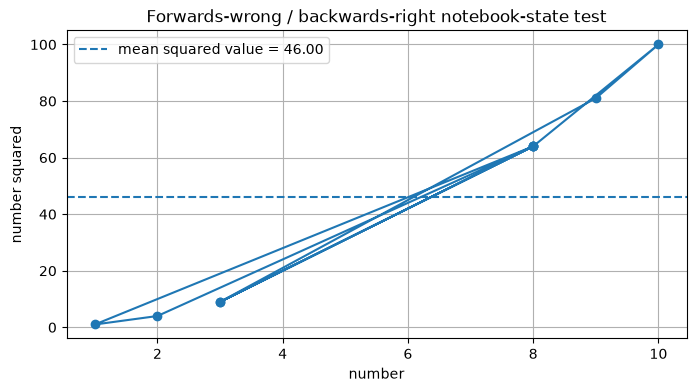

-----------------------------------------------------------------


########################################################################


In [60]:
##  Code cell 50, ~~ANYTHING NEW?~~ Nope, a review

########################################
##     REMEMBER TO MATCH NUMBERS!     ##
########################################

display_banner("#", 72)
print()
display_banner()
show_artifact(22)
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(23)
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(24)
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(25)
display_banner()
print(); print()
display_banner("#", 72)

---

**~~New~~ Review stuff after Code cell 50**

<details>
<summary>Click the right-pointing triangle to see 
    the file contents. 
    Note that any internal HTML should be escaped,
    and downward-pointing triangles should come
    before expanded <code>&lt;detail&gt;</code>,
    <code>&lt;summary&gt;</code> pairs.</summary>

For the **manifest** (Code cell 49)

<pre>
-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 25

000006 | 000002 | stdout | text/plain | tee-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782480662270_2026-06-26T093102270-0400_tee-basic-stdout.txt
000007 | 000002 | display | text/plain | tee-basic-display-01-01-text | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1782480662281_2026-06-26T093102281-0400_tee-basic-display-01-01-text.txt
000008 | 000003 | input | text/x-python | abc-state-reset-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1782480744614_2026-06-26T093224614-0400_abc-state-reset-input.py
000009 | 000003 | stdout | text/plain | abc-state-reset-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1782480744633_2026-06-26T093224633-0400_abc-state-reset-stdout.txt
000010 | 000004 | input | text/x-python | abc-first-pass-a-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1782481023043_2026-06-26T093703043-0400_abc-first-pass-a-input.py
000011 | 000004 | exception | text/plain | abc-first-pass-a-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1782481023504_2026-06-26T093703504-0400_abc-first-pass-a-exception.txt
000012 | 000005 | input | text/x-python | abc-first-pass-a-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000012_1782483189698_2026-06-26T101309698-0400_abc-first-pass-a-input.py
000013 | 000005 | exception | text/plain | abc-first-pass-a-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000013_1782483189729_2026-06-26T101309729-0400_abc-first-pass-a-exception.txt
000014 | 000006 | input | text/x-python | abc-first-pass-b-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000014_1782485749975_2026-06-26T105549975-0400_abc-first-pass-b-input.py
000015 | 000006 | exception | text/plain | abc-first-pass-b-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000015_1782485750010_2026-06-26T105550010-0400_abc-first-pass-b-exception.txt
000016 | 000007 | input | text/x-python | abc-cell-c-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000016_1782487998909_2026-06-26T113318909-0400_abc-cell-c-input.py
000017 | 000007 | stdout | text/plain | abc-cell-c-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000017_1782487999540_2026-06-26T113319540-0400_abc-cell-c-stdout.txt
000018 | 000008 | input | text/x-python | abc-first-pass-b-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000018_1782489615139_2026-06-26T120015139-0400_abc-first-pass-b-input.py
000019 | 000008 | stdout | text/plain | abc-first-pass-b-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000019_1782489615444_2026-06-26T120015444-0400_abc-first-pass-b-stdout.txt
000020 | 000009 | input | text/x-python | abc-second-pass-b-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000020_1782491917505_2026-06-26T123837505-0400_abc-second-pass-b-input.py
000021 | 000009 | stdout | text/plain | abc-second-pass-b-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000021_1782491917526_2026-06-26T123837526-0400_abc-second-pass-b-stdout.txt
000022 | 000010 | input | text/x-python | abc-second-pass-a-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000022_1782493617170_2026-06-26T130657170-0400_abc-second-pass-a-input.py
000023 | 000010 | stdout | text/plain | abc-second-pass-a-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000023_1782493618189_2026-06-26T130658189-0400_abc-second-pass-a-stdout.txt
000024 | 000010 | display | text/plain | abc-second-pass-a-display-01-01-text | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000024_1782493618203_2026-06-26T130658203-0400_abc-second-pass-a-display-01-01-text.txt
000025 | 000010 | display | image/png | abc-second-pass-a-display-01-02-image | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000025_1782493618216_2026-06-26T130658216-0400_abc-second-pass-a-display-01-02-image.png
-----------------------------------------------------------------
</pre>

---

For the **artifact(s)** (Code cell 50)

<pre>
########################################################################

-----------------------------------------------------------------
artifact_sequence: 000022
capture_sequence: 000010
role: input
label: abc-second-pass-a-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000022_1782493617170_2026-06-26T130657170-0400_abc-second-pass-a-input.py
exists: True

##done before# import matplotlib.plotly as plt
##  P.S. Cell A does not import matplotlib here, because Cell C
##+ will do it before we come back for the successful run of
##+ already did. Same for numpy.
##+ This is intentional notebook-state dependence for the A/B/C test.

avg_value = squared_numbers.mean()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    numbers,
    squared_numbers,
    marker="o",
)

ax.axhline(
    avg_value,
    linestyle="--",
    label=f"mean squared value = {avg_value:.2f}",
)

ax.set_title(
    "Forwards-wrong / backwards-right notebook-state test"
)
ax.set_xlabel("number")
ax.set_ylabel("number squared")
ax.grid(True)
ax.legend()

plot_path = (
    repo_root
    / "jupy_log"
    / "staging"
    / "abc_backwards_right.png"
)

plt.savefig(plot_path, dpi=150, bbox_inches="tight")
print("saved explicit plot file:", plot_path)
print("explicit plot exists:", plot_path.exists())

plt.show()

## 15. Code cell         27 — A, 1st execution: expected failure
#
## and
#
## 20. Code cell (still) 27 — A, 2nd execution: expected success and plot capture
##     call it Code Cell 27|43

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000023
capture_sequence: 000010
role: stdout
label: abc-second-pass-a-stdout
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000023_1782493618189_2026-06-26T130658189-0400_abc-second-pass-a-stdout.txt
exists: True

saved explicit plot file: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\staging\abc_backwards_right.png
explicit plot exists: True

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000024
capture_sequence: 000010
role: display
label: abc-second-pass-a-display-01-01-text
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000024_1782493618203_2026-06-26T130658203-0400_abc-second-pass-a-display-01-01-text.txt
exists: True

&lt;Figure size 800x400 with 1 Axes&gt;
-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000025
capture_sequence: 000010
role: display
label: abc-second-pass-a-display-01-02-image
mime: image/png
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000025_1782493618216_2026-06-26T130658216-0400_abc-second-pass-a-display-01-02-image.png
exists: True

&lt;note-from-the-editor&gt;
  The stuff from here on out is not actually true. I didn't
  realize that I&apos;d set things up for the image to be 
  outputted on the second run. So I&apos;m going to make fake
  HTML comments to highlight that the following part is 
  incorrect.<br/>
  It is true that we only get
    
        &lt;Figure size 800x400 with 1 Axes&gt;
  
  for this output, which is a copy/paste of the output from
  Code cell <strong>50</strong>. But in the Jupyter 
  notebook output for <strong>50</strong>, the
  image of the captured figure is visible for all to see!
&lt;/note-from-the-editor&gt;


########################################################################
</pre>

</details>

<hr/>

For **21** (`Code cell 51 — test ``%jupy_file`` with the saved plot`)

The magic currently appends `-01` to the supplied label because it
supports logging multiple paths in one call.

In [61]:
get_ipython().run_line_magic(
    "jupy_file",
    (
        "--label abc-explicit-plot "
        "--mime image/png "
        f'"{plot_path}"'
    ),
)

## 21. Code cell 51 — test `%jupy_file` with the saved plot

[DONE] Logged image: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000026_1782497377424_2026-06-26T140937424-0400_abc-explicit-plot-01.png


[WindowsPath('D:/David/my_repos_dwb/multimodal-jupy-logger/jupy_log/artifacts/000026_1782497377424_2026-06-26T140937424-0400_abc-explicit-plot-01.png')]

In [62]:
## 22. Code cell 52 — initial manifest inspection and validation

%jupy_inspect

print("\n" + "-" * 72 + "\n")

%jupy_validate

Manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
Root: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
Artifacts: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts
Staging: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\staging
Timelines: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines
Rows: 26

By kind:
  html: 1
  image: 2
  text: 23

By MIME:
  image/png: 2
  text/html: 1
  text/markdown: 1
  text/plain: 12
  text/x-python: 10

------------------------------------------------------------------------

Manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
Rows checked: 26
Missing artifacts: 0


[]

For **23** 
(`## Code cell `
~~Z+5~~ 
` 53 — instantiate a direct logger for programmatic inspection`)

This logger points at the same root as the registered magics.

In [63]:
## 23. Code cell 53 — instantiate a direct logger for programmatic inspection

log_root = repo_root / "jupy_log"
logger = MultimodalJupyLogger(root=log_root)

manifest_rows = logger.read_manifest_rows()

print("log_root:", log_root)
print("manifest:", logger.manifest)
print("artifact directory:", logger.artifacts)
print("manifest rows:", len(manifest_rows))

log_root: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
artifact directory: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts
manifest rows: 26


For **24** (`## Code cell `
~~Z+6~~ 
` 54 — inspect the most recent manifest rows`)

Look for groups corresponding to:

```text
details-summary-markdown-regression
details-summary-html-control
capture-basic
tee-basic
abc-state-reset
abc-first-pass-a
abc-first-pass-b
abc-cell-c
abc-second-pass-b
abc-second-pass-a
abc-explicit-plot
```

In [64]:
## 24. Code cell 54 — inspect the most recent manifest rows

catch_all_row_count = 30
all_rows = manifest_rows[-catch_all_row_count:]

for row in all_rows:
    print(
        row.get("artifact_sequence", ""),
        "capture=" + (row.get("capture_sequence", "") or "-"),
        "role=" + row.get("role", ""),
        "mime=" + row.get("mime", ""),
        "label=" + row.get("label", ""),
    )
##endof:  for row in recent_rows

000001 capture=- role=literal mime=text/markdown label=details-summary-markdown-regression
000002 capture=- role=literal mime=text/html label=details-summary-html-control
000003 capture=000001 role=input mime=text/x-python label=capture-basic-input
000004 capture=000001 role=stdout mime=text/plain label=capture-basic-stdout
000005 capture=000002 role=input mime=text/x-python label=tee-basic-input
000006 capture=000002 role=stdout mime=text/plain label=tee-basic-stdout
000007 capture=000002 role=display mime=text/plain label=tee-basic-display-01-01-text
000008 capture=000003 role=input mime=text/x-python label=abc-state-reset-input
000009 capture=000003 role=stdout mime=text/plain label=abc-state-reset-stdout
000010 capture=000004 role=input mime=text/x-python label=abc-first-pass-a-input
000011 capture=000004 role=exception mime=text/plain label=abc-first-pass-a-exception
000012 capture=000005 role=input mime=text/x-python label=abc-first-pass-a-input
000013 capture=000005 role=excepti

In [65]:
## 25. Code cell 55 — inspect the log tree with `dpypd.tree`

dpypd.tree(
    this_dir=log_root,
    dirs_to_exclude=[
        "__pycache__",
    ],
    files_to_exclude=[
        ".pyc",
    ],
)

+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md
        + 000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
        + 000003_1782480519781_2026-06-26T092839781-0400_capture-basic-input.py
        + 000004_1782480520093_2026-06-26T092840093-0400_capture-basic-stdout.txt
        + 000005_1782480662253_2026-06-26T093102253-0400_tee-basic-input.py
        + 000006_1782480662270_2026-06-26T093102270-0400_tee-basic-stdout.txt
        + 000007_1782480662281_2026-06-26T093102281-0400_tee-basic-display-01-01-text.txt
        + 000008_1782480744614_2026-06-26T093224614-0400_abc-state-reset-input.py
        + 000009_1782480744633_2026-06-26T093224633-0400_abc-state-reset-stdout.txt
        + 000010_1782481023043_2026-06-26T093703043-0400_abc-first-pass-a-input.py
        + 000011_1782481023504_2026-06-26T093703504-0400_abc-first-pass-a-exception.t

In [66]:
## 26. Code cell 56 — use the `wc -l` analog

manifest_line_count = dpypd.count_lines(
    logger.manifest,
    do_print=True,
)

print(
    "Expected manifest data rows:",
    manifest_line_count - 1,
)
print(
    "Rows returned by read_manifest_rows:",
    len(manifest_rows),
)
print(
    "Counts agree:",
    manifest_line_count - 1 == len(manifest_rows),
)

D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv has 27 line(s)
Expected manifest data rows: 26
Rows returned by read_manifest_rows: 26
Counts agree: True


For **27** (`Code cell `
~~Z+9~~
` 57 — use the ``cat`` analog on the manifest`)

Verify visually that:

* `artifact_sequence` increases monotonically
* capture artifacts share a `capture_sequence`
* the first failed A and B have exception rows
* the later B and A have successful output rows
* filenames contain both the sequence and epoch milliseconds

In [67]:
## Code cell 57 — use the `cat` analog on the manifest

dpypd.print_file(
    logger.manifest,
    show_line_numbers=True,
)

    1: artifact_sequence	capture_sequence	timestamp	kind	mime	role	label	path
    2: 000001		1782480093619_2026-06-26T092133619-0400	text	text/markdown	literal	details-summary-markdown-regression	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782480093619_2026-06-26T092133619-0400_details-summary-markdown-regression.md
    3: 000002		1782480116471_2026-06-26T092156471-0400	html	text/html	literal	details-summary-html-control	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782480116471_2026-06-26T092156471-0400_details-summary-html-control.html
    4: 000003	000001	1782480519781_2026-06-26T092839781-0400	text	text/x-python	input	capture-basic-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782480519781_2026-06-26T092839781-0400_capture-basic-input.py
    5: 000004	000001	1782480520093_2026-06-26T092840093-0400	text	text/plain	stdout	capture-basic-stdout	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\art

For **28** (`Code cell `
~~Z+10~~
58` — generate both timelines`)

The equivalent magic calls are:

```python
%jupy_markdown
%jupy_html
```

Using the direct logger here makes the returned paths easy to retain.

In [68]:
## 28. Code cell 58 — generate both timelines

markdown_timeline_path = logger.build_markdown()
html_timeline_path = logger.build_html()

print("Markdown timeline:", markdown_timeline_path)
print("HTML timeline:", html_timeline_path)

[DONE] Markdown timeline written: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines\timeline.md
[DONE] HTML timeline written: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines\timeline.html
Markdown timeline: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines\timeline.md
HTML timeline: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines\timeline.html


In [69]:
## 29. Code cell 59 — count timeline lines

n_markdown_lines = dpypd.count_lines(
    markdown_timeline_path,
    do_print=True,
)

n_html_lines = dpypd.count_lines(
    html_timeline_path,
    do_print=True,
)

D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines\timeline.md has 558 line(s)
D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines\timeline.html has 413 line(s)


For **30** (`Code cell `
~~Z+12~~
` 60 — print the Markdown timeline`)

Things to check:

* artifact and capture sequences appear
* roles appear
* failed A and B occur before successful C, B, and A
* Python input is preserved
* exception text is preserved
* image links are present
* the Markdown `<details>` regression item is probably fenced rather than rendered

---

---

---

<span style="font-size: 350%; font-face: bold;">BIG PRINT MARKDOWN</span>

---

In [70]:
## 30. Code cell 60 — print the Markdown timeline

dpypd.print_file(
    markdown_timeline_path,
    show_line_numbers=False,
)

# Jupyter Log Timeline

**Multimodal Jupy Logger Markdown Timeline**

This log file: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines\timeline.md
Timestamp: 1782497604716_2026-06-26T141324716-0400
Machine, user, etc.: BLACK-MACHINE bball@BLACK-MACHINE

---

---

---


---

## details-summary-markdown-regression

`1782480093619_2026-06-26T092133619-0400` — `text` — `text/markdown`

```
<details>
<summary>Click the arrow to reveal logged Markdown text</summary>

This content was logged as `text/markdown`.

The regression question is whether exported timelines preserve this as
renderable Markdown/HTML or incorrectly turn it into escaped or fenced
source text.

</details>

<!-- ## 9. Code cell 08 — log the original Markdown regression case -->
<!--   If I had left the python comment without the HTML comment,   -->
<!-- + it would have rendered as an `h2`. But you might only see    -->
<!-- + this in the dpypd.print_file version.                        -->

<br/>HTML comments

---

---

<span style="font-size: 500%; font-face: bold;">REALLY BIG PRINT HTML</span>

---

For **31** (`Code cell `
~~Z+13~~
` 61 — inspect the raw HTML timeline source`)

This may be lengthy, but it is useful for this first pass.

Search visually for:

```text
details-summary-markdown-regression
details-summary-html-control
abc-first-pass-a
abc-first-pass-b
abc-second-pass-a
image/png
```

In [71]:
## 31. Code cell 61 — inspect the raw HTML timeline source

dpypd.print_file(
    html_timeline_path,
    show_line_numbers=True,
)

    1: <html>
    2: <body>
    3: <h1>Jupyter Log Timeline</h1>
    4: <pre>
    5: **Multimodal Jupy Logger HTML Timeline**
    6: 
    7: This log file: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines\timeline.html
    8: Timestamp: 1782497604760_2026-06-26T141324760-0400
    9: Machine, user, etc.: BLACK-MACHINE bball@BLACK-MACHINE
   10: 
   11: ---
   12: 
   13: ---
   14: 
   15: ---
   16: 
   17: </pre>
   18: <hr>
   19: <h3>details-summary-markdown-regression</h3>
   20: <p><code>1782480093619_2026-06-26T092133619-0400</code> — text — text/markdown</p>
   21: <pre>&lt;details&gt;
   22: &lt;summary&gt;Click the arrow to reveal logged Markdown text&lt;/summary&gt;
   23: 
   24: This content was logged as `text/markdown`.
   25: 
   26: The regression question is whether exported timelines preserve this as
   27: renderable Markdown/HTML or incorrectly turn it into escaped or fenced
   28: source text.
   29: 
   30: &lt;/details&gt;
   31: 
   32: &lt;!-- ##

---

<span style="font-size: 250%; font-face: bold;">THAT WAS THE HTML CODE</span>

---

For **32** (`Code cell `
~~Z+14~~
` 62 — render the generated HTML timeline in the notebook`)

Regression expectations:

* the `text/html` control should show a clickable `<details>` arrow
* the `text/markdown` version may show escaped `<details>` source
* the successful A plot should appear if its captured `image/png` path is
  usable from the generated timeline
* exception entries should be visible in chronological artifact order

---

<span style="font-size: 350%; font-face: bold;">HERE COMES THE RENDERED HTML</span>

---

In [72]:
## 32. Code cell 62 — render the generated HTML timeline in the notebook

from IPython.display import HTML, display

display(
    HTML(
        filename=str(html_timeline_path),
    )
)

---

<span style="font-size:200%;">Okay, kamMA, I got the file paths 
    as they exist in the HTML text, specifically, from:</span>
<br/><br/>
<code>&nbsp;&nbsp; 405: &lt;h3&gt;abc-second-pass-a-display-01-02-image&lt;/h3&gt;
&nbsp;&nbsp; 406: &lt;p&gt;&lt;code&gt;1782493618216_2026-06-26T130658216-0400&lt;/code&gt; — image — image/png&lt;/p&gt;
&nbsp;&nbsp; 407: &lt;img src="D:\\David\\my_repos_dwb\\multimodal-jupy-logger\\jupy_log\\artifacts\\000025_1782493618216_2026-06-26T130658216-0400_abc-second-pass-a-display-01-02-image.png" style="max-width:100%; height:auto;"&gt;
&nbsp;&nbsp; 408: &lt;hr&gt;
&nbsp;&nbsp; 409: &lt;h3&gt;abc-explicit-plot-01&lt;/h3&gt;
&nbsp;&nbsp; 410: &lt;p&gt;&lt;code&gt;1782497377424_2026-06-26T140937424-0400&lt;/code&gt; — image — image/png&lt;/p&gt;
&nbsp;&nbsp; 411: &lt;img src="D:\\David\\my_repos_dwb\\multimodal-jupy-logger\\jupy_log\\artifacts\\000026_1782497377424_2026-06-26T140937424-0400_abc-explicit-plot-01.png" style="max-width:100%; height:auto;"&gt;
</code>
<br/><hr/><br/>
<span style="font-size:200%;">So, I checked both of them by copying 
    and pasting them into Windows File Explorer; they were both found 
    and displayed.</span>
<br/><br/>
<strong>First</strong><br/>
<p>D:\\David\\my_repos_dwb\\multimodal-jupy-logger\\<wbr>jupy_log\\artifacts\\000025_1782493618216_2026-06-26T130658216-0400_<wbr>abc-second-pass-a-display-01-02-image.png<p>
<br/><br/>
<strong>Second</strong><br/>
<p>D:\\David\\my_repos_dwb\\multimodal-jupy-logger\\<wbr>jupy_log\\artifacts\\000025_1782493618216_2026-06-26T130658216-0400_<wbr>abc-second-pass-a-display-01-02-image.png</p>
<br/><hr/><br/>
I&apos;m pretty sure that the issue is that the HTML server for a 
Jupyter notebook doesn&apos;t recognize either 
a <code>C:\\</code> or a <code>D:\\</code>, but rather only its root. 
I'm not sure how to make things portable from here.    
<br/><hr/><br/>
<span style="font-size: 200%">After that, I just have 
    one more question. Is it by design that the little 
    notes taken in a code cell with...</span>

... (what was it?) ... 
<code>%%jupy_log --label details-summary-markdown-regression --mime text/markdown</code>
or the same with <code>--mime text/html</code> gets 
no <code>capture_sequence</code> value, yet still
gets put into the final timeline? I noted this
before, but now I think it's a feature and not a
bug. <span style="font-size:200%;">kamMA,</span> what
is the story. I cannot remember and will not go
look, but this shows the idea.

<pre>000001 capture=- role=literal mime=text/markdown label=details-summary-markdown-regression
000002 capture=- role=literal mime=text/html label=details-summary-html-control</pre>

...

<pre>000026 capture=- role=file mime=image/png label=abc-explicit-plot-01</pre>

---

In [73]:
## 33. Code cell 63 — final validation after exports

missing_paths = logger.validate_manifest()

print("\nFinal status:")
print("  manifest rows:", len(logger.read_manifest_rows()))
print("  missing artifact paths:", len(missing_paths))
print("  Markdown timeline exists:", markdown_timeline_path.exists())
print("  HTML timeline exists:", html_timeline_path.exists())
print("  explicit plot source exists:", plot_source_path.exists())

Manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
Rows checked: 26
Missing artifacts: 0

Final status:
  manifest rows: 26
  missing artifact paths: 0
  Markdown timeline exists: True
  HTML timeline exists: True


NameError: name 'plot_source_path' is not defined

<span style="font-size:200%;">And, kamMA, of course; right here
at the second-to-last code cell, we get an exception.</span>

```text
---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[73], line 10
      6 print("  manifest rows:", len(logger.read_manifest_rows()))
      7 print("  missing artifact paths:", len(missing_paths))
      8 print("  Markdown timeline exists:", markdown_timeline_path.exists())
      9 print("  HTML timeline exists:", html_timeline_path.exists())
---> 10 print("  explicit plot source exists:", plot_source_path.exists())

NameError: name 'plot_source_path' is not defined
```

One variable, that's it.

<span style="font-size:200%;">However, kamMA, The last
cell executed without problem.</span>

In [74]:
## 34. Code cell 64 — final ordering assertions

final_rows = logger.read_manifest_rows()

artifact_sequences = [
    int(row["artifact_sequence"])
    for row in final_rows
]

sequences_are_monotonic = (
    artifact_sequences
    == sorted(artifact_sequences)
)

sequences_are_unique = (
    len(artifact_sequences)
    == len(set(artifact_sequences))
)

filenames_have_sequence_prefixes = all(
    pathlib.Path(row["path"]).name.startswith(
        f"{int(row['artifact_sequence']):06d}_"
    )
    for row in final_rows
)

print("Artifact sequences monotonic:", sequences_are_monotonic)
print("Artifact sequences unique:", sequences_are_unique)
print(
    "Filenames begin with artifact sequence:",
    filenames_have_sequence_prefixes,
)

Artifact sequences monotonic: True
Artifact sequences unique: True
Filenames begin with artifact sequence: True


<hr/>

<span style="font-size:200%;">Any other comments are welcome, 
kamMA. I&apos;d appreciate you going through the checklist, of 
because I think I've burned out my thinker for today ; )</span>

Dave a.k.a. GitHub @bballdave025 a.k.a DWB, 
<hr/>

## 35. Markdown cell — record the result

### Test-result notes

Record the observations here:

- [ ] repository-root discovery worked
- [ ] imports worked
- [ ] utility module alias worked
- [ ] individual utility imports worked
- [ ] magics registered
- [ ] notebook-native `<details>` worked
- [ ] `text/markdown` regression behavior observed
- [ ] `text/html` control rendered
- [ ] `%%jupy_capture` executed and logged
- [ ] `%%jupy_tee` executed and logged
- [ ] first A failed as expected
- [ ] first B failed as expected
- [ ] C succeeded
- [ ] second B succeeded
- [ ] second A succeeded
- [ ] inline Matplotlib plot was captured
- [ ] explicit `%jupy_file` plot was logged
- [ ] manifest sequences were monotonic
- [ ] capture groups were visible
- [ ] filenames contained millisecond timestamps
- [ ] validation reported no missing artifacts
- [ ] Markdown timeline was generated
- [ ] HTML timeline was generated
- [ ] timeline execution history was reconstructable

And now, <span style="font-size:200%;">kamMA,</span> for a more formal sign-off, with no mistakes withheld.

```Windows PowerShell
Windows PowerShell
Copyright (C) Microsoft Corporation. All rights reserved.

Install the latest PowerShell for new features and improvements! https://aka.ms/PSWindows

PS C:\Users\bball> cd D:\David\my_repos_dwb\multimodal-jupy-logger
PS D:\David\my_repos_dwb\multimodal-jupy-logger> .\.venv_mmjl_test\Scripts\Activate.ps1
.\.venv_mmjl_test\Scripts\Activate.ps1 : File
D:\David\my_repos_dwb\multimodal-jupy-logger\.venv_mmjl_test\Scripts\Activate.ps1 cannot be loaded because running
scripts is disabled on this system. For more information, see about_Execution_Policies at
https:/go.microsoft.com/fwlink/?LinkID=135170.
At line:1 char:1
+ .\.venv_mmjl_test\Scripts\Activate.ps1
+ ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    + CategoryInfo          : SecurityError: (:) [], PSSecurityException
    + FullyQualifiedErrorId : UnauthorizedAccess
PS D:\David\my_repos_dwb\multimodal-jupy-logger> Set-ExecutionPolicy -Scope Process -ExecutionPolicy Bypass
PS D:\David\my_repos_dwb\multimodal-jupy-logger> .\.venv_mmjl_test\Scripts\Activate.ps1
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> Get-Date -Format "o"
2026-06-26T14:59:36.4876141-04:00
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> git status
On branch initial-code-and-pdf-and-tee
Your branch is up to date with 'origin/initial-code-and-pdf-and-tee'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
        modified:   examples/mmjl_capture_debugging_lab.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> git add .\examples\mmjl_capture_and_state_smoke_test.ipynb
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> git status
On branch initial-code-and-pdf-and-tee
Your branch is up to date with 'origin/initial-code-and-pdf-and-tee'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
        modified:   examples/mmjl_capture_debugging_lab.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> git add .\examples\mmjl_capture_and_state_smoke_test.ipynb
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> git status
On branch initial-code-and-pdf-and-tee
Your branch is up to date with 'origin/initial-code-and-pdf-and-tee'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
        modified:   examples/mmjl_capture_debugging_lab.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> git add --all
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> git status
On branch initial-code-and-pdf-and-tee
Your branch is up to date with 'origin/initial-code-and-pdf-and-tee'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
        modified:   examples/mmjl_capture_debugging_lab.ipynb

(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> git commit "Pre-tutorial tests pass save for one undefined variable a few lines from the end."
error: pathspec 'Pre-tutorial tests pass save for one undefined variable a few lines from the end.' did not match any file(s) known to git
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> git commit -m "Pre-tutorial tests pass save for one undefined variable a few lines from the end."
[initial-code-and-pdf-and-tee 9f9fd22] Pre-tutorial tests pass save for one undefined variable a few lines from the end.
 1 file changed, 3056 insertions(+), 265 deletions(-)
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> git status
On branch initial-code-and-pdf-and-tee
Your branch is ahead of 'origin/initial-code-and-pdf-and-tee' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> git push
Enter passphrase for key '/c/Users/bball/.ssh/id_ed25519':
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 4 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 159.10 KiB | 7.23 MiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To github.com:bballdave025/multimodal-jupy-logger.git
   aed44b8..9f9fd22  initial-code-and-pdf-and-tee -> initial-code-and-pdf-and-tee
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> Get-Date -Format "o"
2026-06-26T15:04:02.4645349-04:00
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> # Signing off for a bit,
>>                                                                       DWB
DWB : The term 'DWB' is not recognized as the name of a cmdlet, function, script file, or operable program. Check the
spelling of the name, or if a path was included, verify that the path is correct and try again.
At line:2 char:71
+ ...                                                                   DWB
+                                                                       ~~~
    + CategoryInfo          : ObjectNotFound: (DWB:String) [], CommandNotFoundException
    + FullyQualifiedErrorId : CommandNotFoundException

(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> # appropriate ending-ish part
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> #  Go to the Jupyter-running cell `
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> #+ I mean browser tab, see if there are remaining
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> #+ saves.
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> git status
On branch initial-code-and-pdf-and-tee
Your branch is up to date with 'origin/initial-code-and-pdf-and-tee'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
        modified:   examples/mmjl_capture_debugging_lab.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> git add --all
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> # my sign-off.
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> git commit -m "Small pre-tutorial notebook tweaks."
[initial-code-and-pdf-and-tee c33c488] Small pre-tutorial notebook tweaks.
 1 file changed, 108 insertions(+)
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> git status
On branch initial-code-and-pdf-and-tee
Your branch is ahead of 'origin/initial-code-and-pdf-and-tee' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> git push
Enter passphrase for key '/c/Users/bball/.ssh/id_ed25519':
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 4 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 2.17 KiB | 318.00 KiB/s, done.
Total 4 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To github.com:bballdave025/multimodal-jupy-logger.git
   9f9fd22..c33c488  initial-code-and-pdf-and-tee -> initial-code-and-pdf-and-tee
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> git status
On branch initial-code-and-pdf-and-tee
Your branch is up to date with 'origin/initial-code-and-pdf-and-tee'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
        modified:   examples/mmjl_capture_debugging_lab.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> #  I've got to commit
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger>
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger>
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> #  And when I'm done, I'll close the Jupyter browser
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> #+ tab, come out and Ctrl + C the running PowerShell
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> #+ if it didn't end on its own (usually the case,)
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> #+ deactivate on the previously-serving-Jupyter-lab
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> #+ propmt, exit that one, deactivate here, and exit
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> #+ here.
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> Get-Date -Format "o"
2026-06-26T15:11:23.2648427-04:00
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> git add --all
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> git status
On branch initial-code-and-pdf-and-tee
Your branch is up to date with 'origin/initial-code-and-pdf-and-tee'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
        modified:   examples/mmjl_capture_debugging_lab.ipynb

(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> git commit -m "Small incremental saves for small, incremental fixes on pre-tutorial notebook."
[initial-code-and-pdf-and-tee b99f22f] Small incremental saves for small, incremental fixes on pre-tutorial notebook.
 1 file changed, 4 insertions(+), 3 deletions(-)
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> git status
On branch initial-code-and-pdf-and-tee
Your branch is ahead of 'origin/initial-code-and-pdf-and-tee' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> git push
Enter passphrase for key '/c/Users/bball/.ssh/id_ed25519':
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 4 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 531 bytes | 531.00 KiB/s, done.
Total 4 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To github.com:bballdave025/multimodal-jupy-logger.git
   c33c488..b99f22f  initial-code-and-pdf-and-tee -> initial-code-and-pdf-and-tee
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> git status
On branch initial-code-and-pdf-and-tee
Your branch is up to date with 'origin/initial-code-and-pdf-and-tee'.

nothing to commit, working tree clean
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> #  Going to deactivate and exit. Times 2
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger> Get-Date -Format "o"
2026-06-26T15:12:26.9180195-04:00
(.venv_mmjl_test) PS D:\David\my_repos_dwb\multimodal-jupy-logger>
```

---

Oh, and one more thing that will make this notebook LONG and require me to commit yet again:

In [75]:
%history

## 2. Code cell 01 — locate the repository root and configure `sys.path`
import importlib
import os
import sys
import pathlib

starting_dir = pathlib.Path.cwd().resolve()
repo_root = None
src_path = None
package_path = None

for candidate_path in [starting_dir, *starting_dir.parents]:
    package_path = (
        candidate_path
        / "src"
        / "multimodal_jupy_logger"
    )

    if package_path.is_dir():
        repo_root = candidate_path
        break
    ##endof:  if package_path.is_dir()
##endof:  for candidate_path in [...]

if repo_root is None:
    raise RuntimeError(
        "Could not find a repository root containing "
        "src/multimodal_jupy_logger."
    )
##endof:  if repo_root is None

src_path = repo_root / "src"

os.chdir(repo_root)

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
##endof:  if str(src_path) not in sys.path

importlib.invalidate_caches()

print("starting_dir:", starting_dir)
print("repo_root:", repo_root)
print("src_p